# 기말고사 문제 4 — Bike Sharing 회귀 + 분류 종합 분석

> **기계학습 라이브러리 활용** · 기말 Take-home Exam
> 배점: **25점** (Part B 10 + Part C 10 + Part D 5)  ·  Part A·B1(EDA/전처리)는 제공 코드

이 문제는 **회귀와 분류를 같은 데이터에서 모두 수행**하는 종합 응용 문제입니다.

---

## 📌 시험 안내

### 데이터
- **출처**: UCI ML Repository — Bike Sharing Dataset (hour-level)
- **URL**: `https://raw.githubusercontent.com/PacktWorkshops/The-Data-Analysis-Workshop/master/Chapter01/data/hour.csv`
- **샘플**: 17,379개 (시간별 2년치)
- **타겟**: `cnt` (시간당 자전거 대여 수, 1~977)

### 두 가지 문제
1. **회귀**: `cnt` 값을 직접 예측 (MAE 평가)
2. **분류**: `cnt`를 3구간(low/mid/high)으로 binning 후 분류 (Accuracy 평가)

### 주의사항
- `casual`과 `registered` 컬럼은 **feature로 사용 금지** (`cnt = casual + registered`이므로 data leakage)
- 학번 마지막 4자리를 seed로 사용

---

## ⚠️ 학번 입력 (필수)

In [1]:
STUDENT_ID = "3085"   # ← 본인 학번 마지막 4자리로 변경
SEED = int(STUDENT_ID)

assert STUDENT_ID != "0000", "학번을 입력하세요!"
print(f'학번(끝4자리): {STUDENT_ID}, SEED: {SEED}')

학번(끝4자리): 3085, SEED: 3085


## 환경 준비

필요한 라이브러리를 import하고 seed를 고정하세요.
(회귀/분류 모두에 필요한 모듈 포함)

In [2]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import keras
from keras import Sequential
from keras.layers import Dense, Dropout, BatchNormalization, Activation
from keras.regularizers import l2
from keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report

# 재현성: 학번 기반 SEED로 고정 (numpy + 현재 keras 백엔드 동시 고정)
np.random.seed(SEED)
keras.utils.set_random_seed(SEED)

print('Keras  :', keras.__version__, '| backend:', keras.backend.backend())
print('pandas :', pd.__version__)

I0000 00:00:1781882366.794341  572260 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781882366.795595  572260 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


I0000 00:00:1781882369.084107  572260 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781882369.084557  572260 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Keras  : 3.14.1 | backend: tensorflow
pandas : 3.0.2


---
# Part A. 데이터 EDA + Feature Engineering (제공 코드)

## A1. 데이터 로드 및 기본 정보

- 데이터 로드 및 shape 출력
- 결측치 확인
- 컬럼 목록 출력
- `cnt` 컬럼의 기본 통계 출력


In [3]:
url = 'https://raw.githubusercontent.com/PacktWorkshops/The-Data-Analysis-Workshop/master/Chapter01/data/hour.csv'
df = pd.read_csv(url)

print(f'Shape: {df.shape}')
print(f'결측치: {df.isnull().sum().sum()}')
print(f'\n컬럼: {df.columns.tolist()}')
print(f'\ncnt 분포:')
print(df['cnt'].describe())

Shape: (17379, 17)
결측치: 0

컬럼: ['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']

cnt 분포:
count    17379.000000
mean       189.463088
std        181.387599
min          1.000000
25%         40.000000
50%        142.000000
75%        281.000000
max        977.000000
Name: cnt, dtype: float64


## A2. 타겟 분포 시각화

- `cnt`의 원본 히스토그램과 log 변환 후 히스토그램을 나란히 비교
- 각 분포의 skewness 출력
- 어느 쪽이 회귀에 적합한지 판단 (마크다운으로 1줄)


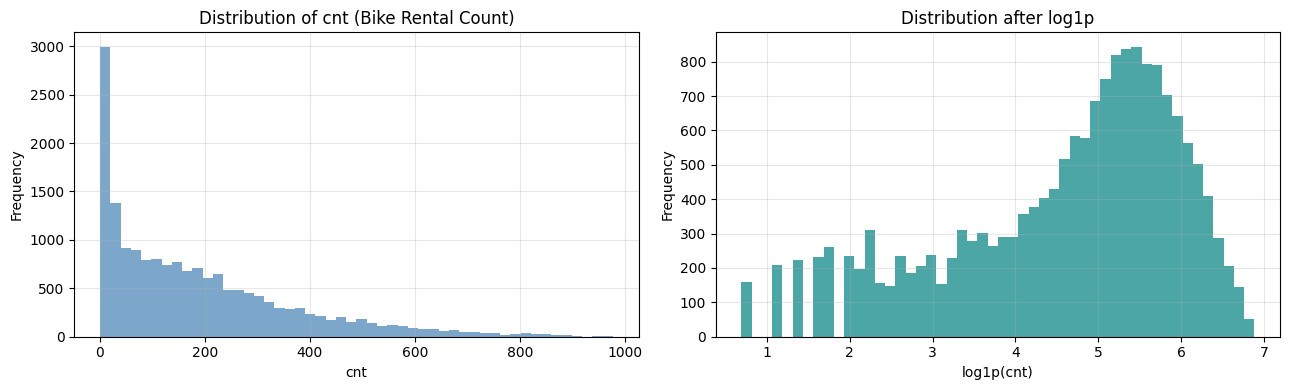

원본 skewness: 1.28
log 변환 후  : -0.82
 === A1. Bike Sharing 데이터 컬럼 역할 정의 ===


,column,role,raw meaning,domain meaning,modeling decision
0,instant,id,record index,행 번호. 관측 순서 ID,feature에서 제외
1,dteday,date,date,날짜. 시간 정보 원천,직접 feature 제외. 필요하면 파생변수만 사용
2,season,categorical_feature,"1:winter, 2:spring, 3:summer, 4:fall",계절. 수요의 장기 패턴,사용 가능
3,yr,categorical/time_feature,"0:2011, 1:2012",연도. 서비스 성장 또는 연도 효과,사용 가능
4,mnth,categorical/time_feature,1~12,월. 계절성과 월별 수요 패턴,사용 가능
5,hr,categorical/time_feature,0~23,시간대. 출퇴근/야간/낮 패턴 핵심,사용 가능
6,holiday,binary_feature,0/1,공휴일 여부,사용 가능
7,weekday,categorical_feature,day of week,요일. 주말/평일 패턴,사용 가능
8,workingday,binary_feature,0/1,주말/공휴일이 아니면 1,사용 가능
9,weathersit,categorical_feature,1~4,날씨 상태. 맑음/흐림/비/눈 등,사용 가능


 === A1-1. 기본 데이터 점검 ===
Shape: (17379, 17)
결측치 총 개수: 0
중복 instant 개수: 0
날짜 범위: 2011-01-01 00:00:00 ~ 2012-12-31 00:00:00
시간 hr 범위: 0 ~ 23
cnt 범위: 1 ~ 977

 === A1-2. Leakage 확인: casual + registered == cnt ===
(casual + registered == cnt) 비율: 1.0000

해석:
casual과 registered는 cnt의 직접 구성요소이므로 feature에 포함하면 data leakage가 발생한다.
따라서 회귀/분류 모두 X에서는 casual, registered, cnt, instant, dteday를 제외한다.
 === A2. Target(cnt) 분포 심화 확인 ===
RQ0. cnt는 정규분포에 가까운가, 아니면 특정 시간대에 수요가 몰리는 long-tail count target인가?


count    17379.000000
mean       189.463088
std        181.387599
min          1.000000
1%           2.000000
5%           5.000000
25%         40.000000
50%        142.000000
75%        281.000000
90%        451.200000
95%        563.100000
99%        782.220000
max        977.000000
Name: cnt, dtype: float64

원본 skewness: 1.2774
원본 kurtosis: 1.4172
log1p skewness: -0.8182
log1p kurtosis: -0.1795


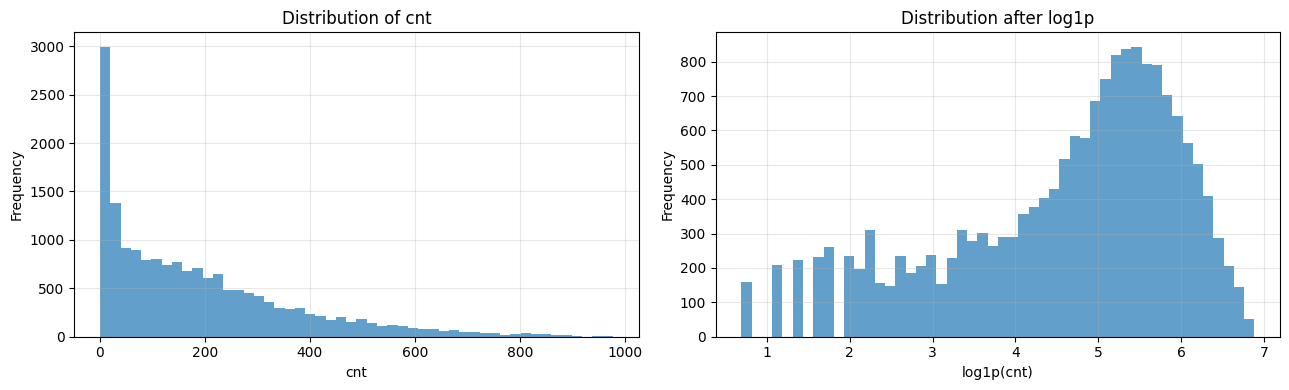

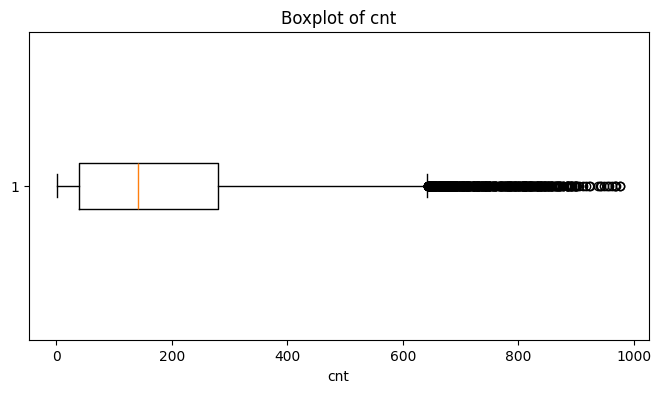

해석:
cnt는 평균이 중앙값보다 크고, max가 977로 높아 오른쪽 꼬리가 존재한다.
이는 특정 시간대, 계절, 날씨 조건에서 대여량이 급증하는 demand peak가 있다는 뜻이다.
원본 cnt를 그대로 MSE로 학습하면 고수요 시간대의 큰 오차가 loss를 강하게 지배할 수 있다.
log1p(cnt)는 큰 값을 압축해 회귀 학습을 안정화할 수 있다.
따라서 Part B 회귀에서는 y에 log1p 변환을 적용하고, 최종 평가는 expm1으로 원본 스케일 복원 후 MAE를 계산하는 것이 적절하다.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# 히스토그램
axes[0].hist(df['cnt'], bins=50, color='steelblue', alpha=0.7)
axes[0].set_xlabel('cnt'); axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of cnt (Bike Rental Count)')
axes[0].grid(alpha=0.3)

# log 변환 후
axes[1].hist(np.log1p(df['cnt']), bins=50, color='teal', alpha=0.7)
axes[1].set_xlabel('log1p(cnt)'); axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution after log1p')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f'원본 skewness: {df["cnt"].skew():.2f}')
print(f'log 변환 후  : {np.log1p(df["cnt"]).skew():.2f}')

print(' === A1. Bike Sharing 데이터 컬럼 역할 정의 ===')

column_role_table = pd.DataFrame([
    ['instant', 'id', 'record index', '행 번호. 관측 순서 ID', 'feature에서 제외'],
    ['dteday', 'date', 'date', '날짜. 시간 정보 원천', '직접 feature 제외. 필요하면 파생변수만 사용'],
    ['season', 'categorical_feature', '1:winter, 2:spring, 3:summer, 4:fall', '계절. 수요의 장기 패턴', '사용 가능'],
    ['yr', 'categorical/time_feature', '0:2011, 1:2012', '연도. 서비스 성장 또는 연도 효과', '사용 가능'],
    ['mnth', 'categorical/time_feature', '1~12', '월. 계절성과 월별 수요 패턴', '사용 가능'],
    ['hr', 'categorical/time_feature', '0~23', '시간대. 출퇴근/야간/낮 패턴 핵심', '사용 가능'],
    ['holiday', 'binary_feature', '0/1', '공휴일 여부', '사용 가능'],
    ['weekday', 'categorical_feature', 'day of week', '요일. 주말/평일 패턴', '사용 가능'],
    ['workingday', 'binary_feature', '0/1', '주말/공휴일이 아니면 1', '사용 가능'],
    ['weathersit', 'categorical_feature', '1~4', '날씨 상태. 맑음/흐림/비/눈 등', '사용 가능'],
    ['temp', 'numeric_feature', 'normalized temperature', '정규화된 기온', '사용 가능'],
    ['atemp', 'numeric_feature', 'normalized feeling temperature', '정규화된 체감온도', '사용 가능'],
    ['hum', 'numeric_feature', 'normalized humidity', '정규화된 습도', '사용 가능'],
    ['windspeed', 'numeric_feature', 'normalized wind speed', '정규화된 풍속', '사용 가능'],
    ['casual', 'leakage', 'casual user count', '비회원/일회성 사용자 대여량', 'cnt 구성요소이므로 제외'],
    ['registered', 'leakage', 'registered user count', '등록 사용자 대여량', 'cnt 구성요소이므로 제외'],
    ['cnt', 'target', 'casual + registered', '총 대여량. 회귀 target 또는 분류 binning 기준', 'y']
], columns=['column', 'role', 'raw meaning', 'domain meaning', 'modeling decision'])

display(column_role_table)

print(' === A1-1. 기본 데이터 점검 ===')
print(f'Shape: {df.shape}')
print(f'결측치 총 개수: {df.isnull().sum().sum()}')
print(f'중복 instant 개수: {df["instant"].duplicated().sum()}')

df_audit = df.copy()
df_audit['dteday'] = pd.to_datetime(df_audit['dteday'])

print(f'날짜 범위: {df_audit["dteday"].min()} ~ {df_audit["dteday"].max()}')
print(f'시간 hr 범위: {df["hr"].min()} ~ {df["hr"].max()}')
print(f'cnt 범위: {df["cnt"].min()} ~ {df["cnt"].max()}')

print('\n === A1-2. Leakage 확인: casual + registered == cnt ===')
leakage_match_rate = ((df['casual'] + df['registered']) == df['cnt']).mean()
print(f'(casual + registered == cnt) 비율: {leakage_match_rate:.4f}')

print('\n해석:')
print('casual과 registered는 cnt의 직접 구성요소이므로 feature에 포함하면 data leakage가 발생한다.')
print('따라서 회귀/분류 모두 X에서는 casual, registered, cnt, instant, dteday를 제외한다.')

print(' === A2. Target(cnt) 분포 심화 확인 ===')
print('RQ0. cnt는 정규분포에 가까운가, 아니면 특정 시간대에 수요가 몰리는 long-tail count target인가?')

target = 'cnt'

cnt_desc = df[target].describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

display(cnt_desc)

cnt_skew = df[target].skew()
cnt_kurt = df[target].kurtosis()
log_cnt = np.log1p(df[target])
log_cnt_skew = log_cnt.skew()
log_cnt_kurt = log_cnt.kurtosis()

print(f'원본 skewness: {cnt_skew:.4f}')
print(f'원본 kurtosis: {cnt_kurt:.4f}')
print(f'log1p skewness: {log_cnt_skew:.4f}')
print(f'log1p kurtosis: {log_cnt_kurt:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df['cnt'], bins=50, alpha=0.7)
axes[0].set_xlabel('cnt')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of cnt')
axes[0].grid(alpha=0.3)

axes[1].hist(np.log1p(df['cnt']), bins=50, alpha=0.7)
axes[1].set_xlabel('log1p(cnt)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution after log1p')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.boxplot(df['cnt'], vert=False)
plt.title('Boxplot of cnt')
plt.xlabel('cnt')
plt.show()

print('해석:')
print('cnt는 평균이 중앙값보다 크고, max가 977로 높아 오른쪽 꼬리가 존재한다.')
print('이는 특정 시간대, 계절, 날씨 조건에서 대여량이 급증하는 demand peak가 있다는 뜻이다.')
print('원본 cnt를 그대로 MSE로 학습하면 고수요 시간대의 큰 오차가 loss를 강하게 지배할 수 있다.')
print('log1p(cnt)는 큰 값을 압축해 회귀 학습을 안정화할 수 있다.')
print('따라서 Part B 회귀에서는 y에 log1p 변환을 적용하고, 최종 평가는 expm1으로 원본 스케일 복원 후 MAE를 계산하는 것이 적절하다.')


## A3. Feature Engineering

- 기존 데이터에서 *유용한 feature 1개 이상 추가* (예: 시간대 그룹, 주말 등)
- 추가한 feature가 범주형이면 One-Hot 인코딩
- ⚠️ **반드시 `casual`과 `registered`를 feature에서 제외** (data leakage 방지)
- ⚠️ `instant`, `dteday`, `cnt`도 feature에서 제외

**출력**:
- 최종 feature 컬럼 목록
- X.shape



In [5]:
df_clean = df.copy()

# 시간대 그룹 (rush hour 등의 패턴 반영)
def time_of_day(h):
    if 6 <= h <= 9:  return 'morning_rush'
    elif 10 <= h <= 16: return 'daytime'
    elif 17 <= h <= 20: return 'evening_rush'
    else: return 'night'
df_clean['time_group'] = df_clean['hr'].apply(time_of_day)

# 주말 여부 (workingday를 그대로 써도 됨)
df_clean['is_weekend'] = (df_clean['weekday'].isin([0, 6])).astype(int)

# Feature 선택 (casual, registered는 cnt의 직접 분해이므로 제외)
# date, instant도 제외
feature_cols = [
    'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit',
    'temp', 'atemp', 'hum', 'windspeed',
    'is_weekend'
]

# time_group은 범주형 → One-Hot
df_encoded = pd.get_dummies(df_clean[feature_cols + ['time_group']],
                            columns=['time_group'], dtype=int)

X = df_encoded.values.astype(np.float32)
y_reg = df_clean['cnt'].values.astype(np.float32)

print(f'X shape: {X.shape}')
print(f'Feature 컬럼 수: {X.shape[1]}')
print(f'Feature 목록: {df_encoded.columns.tolist()}')

X shape: (17379, 17)
Feature 컬럼 수: 17
Feature 목록: ['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'is_weekend', 'time_group_daytime', 'time_group_evening_rush', 'time_group_morning_rush', 'time_group_night']


In [6]:
print(' === A3-1. Feature Engineering 결과 검증 ===')

print(f'df_clean shape : {df_clean.shape}')
print(f'df_encoded shape: {df_encoded.shape}')
print(f'X shape        : {X.shape}')
print(f'y_reg shape    : {y_reg.shape}')

print('\n[Feature columns]')
display(pd.DataFrame({
    'feature_index': np.arange(len(df_encoded.columns)),
    'feature_name': df_encoded.columns.tolist(),
    'dtype': [df_encoded[c].dtype for c in df_encoded.columns]
}))

print('\n[Leakage column check]')
leakage_cols = ['casual', 'registered', 'cnt', 'instant', 'dteday']
leakage_in_features = [c for c in leakage_cols if c in df_encoded.columns]

print(f'feature에 포함된 leakage 후보: {leakage_in_features}')

if len(leakage_in_features) == 0:
    print('결론: casual, registered, cnt, instant, dteday가 X에서 제외되었으므로 leakage 통제가 적절하다.')
else:
    print('주의: leakage 가능 컬럼이 feature에 포함되어 있다. 반드시 제거해야 한다.')

print('\n[time_group one-hot check]')
time_group_cols = [c for c in df_encoded.columns if c.startswith('time_group_')]
print(f'time_group dummy columns: {time_group_cols}')
print(df_encoded[time_group_cols].sum())

print('\n해석:')
print('A3에서는 시간대 구조를 반영하기 위해 hr를 morning_rush/daytime/evening_rush/night로 파생했다.')
print('또한 weekday에서 is_weekend를 만들었다.')
print('이 두 feature는 A8의 시간대 수요 구조 가설과 직접 연결된다.')
print('casual과 registered는 cnt의 직접 구성요소이므로 feature에서 제외했다.')

 === A3-1. Feature Engineering 결과 검증 ===
df_clean shape : (17379, 19)
df_encoded shape: (17379, 17)
X shape        : (17379, 17)
y_reg shape    : (17379,)

[Feature columns]


,feature_index,feature_name,dtype
0,0,season,int64
1,1,yr,int64
2,2,mnth,int64
3,3,hr,int64
4,4,holiday,int64
5,5,weekday,int64
6,6,workingday,int64
7,7,weathersit,int64
8,8,temp,float64
9,9,atemp,float64



[Leakage column check]
feature에 포함된 leakage 후보: []
결론: casual, registered, cnt, instant, dteday가 X에서 제외되었으므로 leakage 통제가 적절하다.

[time_group one-hot check]
time_group dummy columns: ['time_group_daytime', 'time_group_evening_rush', 'time_group_morning_rush', 'time_group_night']
time_group_daytime         5099
time_group_evening_rush    2914
time_group_morning_rush    2906
time_group_night           6460
dtype: int64

해석:
A3에서는 시간대 구조를 반영하기 위해 hr를 morning_rush/daytime/evening_rush/night로 파생했다.
또한 weekday에서 is_weekend를 만들었다.
이 두 feature는 A8의 시간대 수요 구조 가설과 직접 연결된다.
casual과 registered는 cnt의 직접 구성요소이므로 feature에서 제외했다.


 === A4. EDA 기반 귀무가설 후보 3개 설정 ===


,id,axis,H0,H1,evidence_to_check,model_connection
0,H0-1,시간대 수요 구조,"hr, time_group, workingday에 따라 cnt 분포 차이가 없다.",시간대와 근무일 구조에 따라 cnt 분포가 달라진다.,"hour별 평균, workingday별 hour profile, time_group...","hr, workingday, weekday, holiday, time_group을 ..."
1,H0-2,날씨·쾌적성 구조,"temp, atemp, hum, windspeed, weathersit은 cnt와 ...",날씨·쾌적성 변수는 자전거 대여량과 관련된다.,"Spearman correlation, weathersit별 평균 cnt","temp, atemp, hum, windspeed, weathersit을 featu..."
2,H0-3,계절·연도 효과,"season, mnth, yr에 따라 cnt 분포 차이가 없다.","계절성, 월별 패턴, 연도 성장 효과가 존재한다.","season별 평균, month trend, yr별 평균","season, mnth, yr를 feature로 유지"


해석:
이 노트북의 EDA는 단순 시각화가 아니라 feature 설계의 근거를 만드는 과정이다.
A3에서 만든 feature set은 시간 구조, 날씨 구조, 계절/연도 구조라는 세 축으로 정리된다.
이 세 가설이 Part B 회귀와 Part C 분류 모델의 입력 X 설계를 정당화한다.
 === A5. H0-1 시간대 / 근무일 / 시간그룹 수요 구조 검정 ===
RQ1. 자전거 대여량은 시간대와 근무일 여부에 따라 다른 패턴을 보이는가?
H0-1: hr, time_group, workingday에 따라 cnt 분포 차이가 없다.
H1-1: 시간대와 근무일 구조에 따라 cnt 분포가 달라진다.


,feature_axis,test,statistic,p_value,decision_0.05,eta_squared_descriptive
0,hr,Kruskal-Wallis,1.097304e+04,0.000000,reject H0,0.501493
1,time_group,Kruskal-Wallis,7.874234e+03,0.000000,reject H0,0.357591
2,workingday,Mann-Whitney U,3.185830e+07,0.005558,reject H0,0.000917


,hr,count,mean,median,std
0,0,726,53.898072,40.0,42.307910
1,1,724,33.375691,20.0,33.538727
2,2,715,22.869930,11.0,26.578642
3,3,697,11.727403,6.0,13.239190
4,4,697,6.352941,6.0,4.143818
5,5,717,19.889819,19.0,13.200765
6,6,725,76.044138,76.0,55.084348
7,7,727,212.064649,208.0,161.441936
8,8,727,359.011004,385.0,235.189285
9,9,727,219.309491,216.0,93.703458


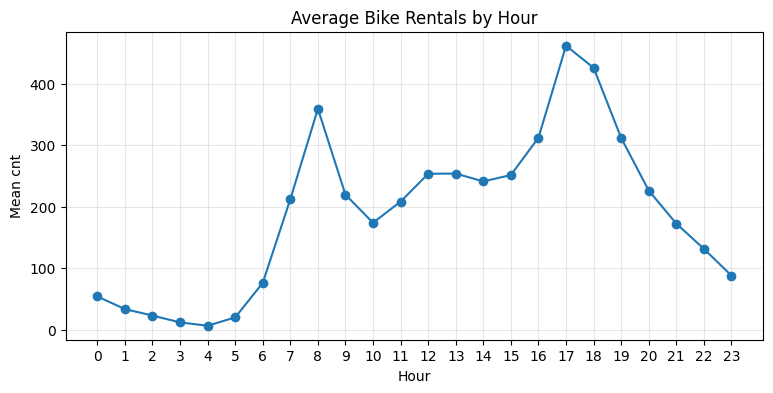

시각화 1 해석:
hour별 평균 cnt를 보면 새벽 시간대에는 수요가 낮고, 아침과 저녁 시간대에 수요가 급격히 커진다.
특히 8시와 17~18시 부근에서 평균 대여량이 크게 올라가므로, hr는 단순 숫자 feature가 아니라 수요 패턴의 핵심 축이다.
따라서 “시간대별 cnt 분포 차이가 없다”는 H0-1은 기각하는 방향으로 해석한다.


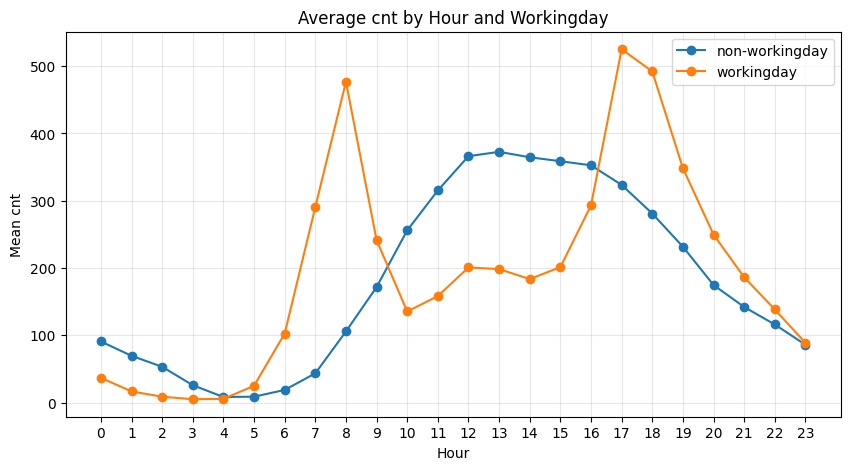

시각화 2 해석:
workingday별 hour profile은 자전거 수요의 도메인 구조를 보여준다.
workingday=1에서는 출근/퇴근 시간대의 commuting demand가 강하게 나타날 가능성이 크다.
workingday=0에서는 출퇴근형 peak보다 낮 시간대 leisure demand가 상대적으로 중요할 수 있다.
따라서 hr와 workingday는 독립적으로만 보는 것이 아니라 hr × workingday interaction 관점에서 해석해야 한다.


,count,mean,median,std
time_group,,,,
evening_rush,2914,356.201441,325.0,211.890752
daytime,5099,241.902138,214.0,144.093134
morning_rush,2906,216.704061,169.0,182.485182
night,6460,60.604799,29.0,72.478411


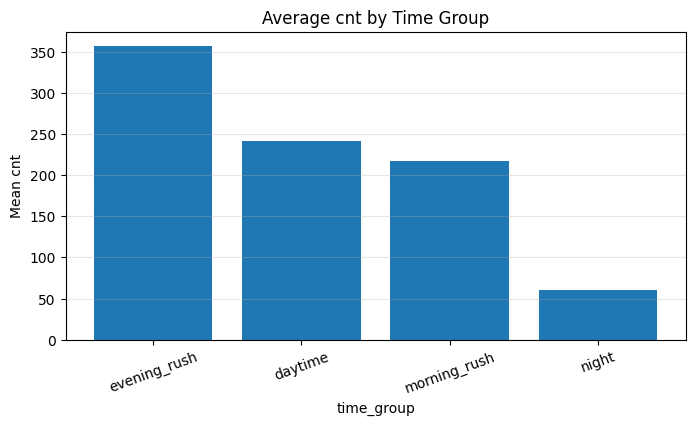

시각화 3 해석:
time_group별 평균을 보면 evening_rush가 가장 높고, night가 가장 낮다.
이는 A3에서 만든 time_group 파생변수가 시간대 수요 구조를 압축하는 유용한 feature임을 보여준다.
최종 결론:
- hr p-value: 0.000e+00, decision: reject H0
- time_group p-value: 0.000e+00, decision: reject H0
- workingday p-value: 5.558e-03, decision: reject H0
==> H0-1은 기각한다. 시간대와 근무일 구조는 cnt 예측의 핵심 feature 축이다.


In [7]:
print(' === A4. EDA 기반 귀무가설 후보 3개 설정 ===')

hypothesis_table = pd.DataFrame([
    {
        'id': 'H0-1',
        'axis': '시간대 수요 구조',
        'H0': 'hr, time_group, workingday에 따라 cnt 분포 차이가 없다.',
        'H1': '시간대와 근무일 구조에 따라 cnt 분포가 달라진다.',
        'evidence_to_check': 'hour별 평균, workingday별 hour profile, time_group별 평균',
        'model_connection': 'hr, workingday, weekday, holiday, time_group을 feature로 유지'
    },
    {
        'id': 'H0-2',
        'axis': '날씨·쾌적성 구조',
        'H0': 'temp, atemp, hum, windspeed, weathersit은 cnt와 관계가 없다.',
        'H1': '날씨·쾌적성 변수는 자전거 대여량과 관련된다.',
        'evidence_to_check': 'Spearman correlation, weathersit별 평균 cnt',
        'model_connection': 'temp, atemp, hum, windspeed, weathersit을 feature로 유지'
    },
    {
        'id': 'H0-3',
        'axis': '계절·연도 효과',
        'H0': 'season, mnth, yr에 따라 cnt 분포 차이가 없다.',
        'H1': '계절성, 월별 패턴, 연도 성장 효과가 존재한다.',
        'evidence_to_check': 'season별 평균, month trend, yr별 평균',
        'model_connection': 'season, mnth, yr를 feature로 유지'
    }
])

display(hypothesis_table)

print('해석:')
print('이 노트북의 EDA는 단순 시각화가 아니라 feature 설계의 근거를 만드는 과정이다.')
print('A3에서 만든 feature set은 시간 구조, 날씨 구조, 계절/연도 구조라는 세 축으로 정리된다.')
print('이 세 가설이 Part B 회귀와 Part C 분류 모델의 입력 X 설계를 정당화한다.')

print(' === A5. H0-1 시간대 / 근무일 / 시간그룹 수요 구조 검정 ===')
print('RQ1. 자전거 대여량은 시간대와 근무일 여부에 따라 다른 패턴을 보이는가?')
print('H0-1: hr, time_group, workingday에 따라 cnt 분포 차이가 없다.')
print('H1-1: 시간대와 근무일 구조에 따라 cnt 분포가 달라진다.')

from scipy.stats import kruskal, mannwhitneyu, spearmanr

def p_decision(p, alpha=0.05):
    return 'reject H0' if p < alpha else 'fail to reject H0'

def eta_squared_by_group(data, group_col, target_col='cnt'):
    temp = data[[group_col, target_col]].dropna().copy()
    overall_mean = temp[target_col].mean()
    ss_between = 0
    
    for _, group in temp.groupby(group_col):
        ss_between += len(group) * (group[target_col].mean() - overall_mean) ** 2
    
    ss_total = ((temp[target_col] - overall_mean) ** 2).sum()
    return ss_between / ss_total if ss_total != 0 else np.nan

def kruskal_group_test(data, group_col, target_col='cnt'):
    groups = [
        g[target_col].dropna().values
        for _, g in data.groupby(group_col)
        if len(g[target_col].dropna()) > 0
    ]
    stat, p = kruskal(*groups)
    eta2 = eta_squared_by_group(data, group_col, target_col)
    return stat, p, eta2

def mannwhitney_binary_test(data, group_col, target_col='cnt'):
    g0 = data[data[group_col] == 0][target_col].dropna().values
    g1 = data[data[group_col] == 1][target_col].dropna().values
    stat, p = mannwhitneyu(g0, g1, alternative='two-sided')
    eta2 = eta_squared_by_group(data, group_col, target_col)
    return stat, p, eta2

hr_stat, hr_p, hr_eta2 = kruskal_group_test(df_clean, 'hr')
tg_stat, tg_p, tg_eta2 = kruskal_group_test(df_clean, 'time_group')
wd_stat, wd_p, wd_eta2 = mannwhitney_binary_test(df_clean, 'workingday')

time_test_result = pd.DataFrame([
    ['hr', 'Kruskal-Wallis', hr_stat, hr_p, p_decision(hr_p), hr_eta2],
    ['time_group', 'Kruskal-Wallis', tg_stat, tg_p, p_decision(tg_p), tg_eta2],
    ['workingday', 'Mann-Whitney U', wd_stat, wd_p, p_decision(wd_p), wd_eta2]
], columns=['feature_axis', 'test', 'statistic', 'p_value', 'decision_0.05', 'eta_squared_descriptive'])

display(time_test_result)

hour_pattern = df_clean.groupby('hr')['cnt'].agg(['count', 'mean', 'median', 'std']).reset_index()
display(hour_pattern)

plt.figure(figsize=(9, 4))
plt.plot(hour_pattern['hr'], hour_pattern['mean'], marker='o')
plt.title('Average Bike Rentals by Hour')
plt.xlabel('Hour')
plt.ylabel('Mean cnt')
plt.xticks(range(0, 24))
plt.grid(alpha=0.3)
plt.show()

print('시각화 1 해석:')
print('hour별 평균 cnt를 보면 새벽 시간대에는 수요가 낮고, 아침과 저녁 시간대에 수요가 급격히 커진다.')
print('특히 8시와 17~18시 부근에서 평균 대여량이 크게 올라가므로, hr는 단순 숫자 feature가 아니라 수요 패턴의 핵심 축이다.')
print('따라서 “시간대별 cnt 분포 차이가 없다”는 H0-1은 기각하는 방향으로 해석한다.')

working_hour_pattern = df_clean.groupby(['hr', 'workingday'])['cnt'].mean().reset_index()

plt.figure(figsize=(10, 5))
for wd_value, label in [(0, 'non-workingday'), (1, 'workingday')]:
    temp = working_hour_pattern[working_hour_pattern['workingday'] == wd_value]
    plt.plot(temp['hr'], temp['cnt'], marker='o', label=label)

plt.title('Average cnt by Hour and Workingday')
plt.xlabel('Hour')
plt.ylabel('Mean cnt')
plt.xticks(range(0, 24))
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print('시각화 2 해석:')
print('workingday별 hour profile은 자전거 수요의 도메인 구조를 보여준다.')
print('workingday=1에서는 출근/퇴근 시간대의 commuting demand가 강하게 나타날 가능성이 크다.')
print('workingday=0에서는 출퇴근형 peak보다 낮 시간대 leisure demand가 상대적으로 중요할 수 있다.')
print('따라서 hr와 workingday는 독립적으로만 보는 것이 아니라 hr × workingday interaction 관점에서 해석해야 한다.')

time_group_summary = df_clean.groupby('time_group')['cnt'].agg(
    count='count',
    mean='mean',
    median='median',
    std='std'
).sort_values('mean', ascending=False)

display(time_group_summary)

plt.figure(figsize=(8, 4))
plt.bar(time_group_summary.index, time_group_summary['mean'])
plt.title('Average cnt by Time Group')
plt.xlabel('time_group')
plt.ylabel('Mean cnt')
plt.xticks(rotation=20)
plt.grid(axis='y', alpha=0.3)
plt.show()

print('시각화 3 해석:')
print('time_group별 평균을 보면 evening_rush가 가장 높고, night가 가장 낮다.')
print('이는 A3에서 만든 time_group 파생변수가 시간대 수요 구조를 압축하는 유용한 feature임을 보여준다.')

print('최종 결론:')
print(f'- hr p-value: {hr_p:.3e}, decision: {p_decision(hr_p)}')
print(f'- time_group p-value: {tg_p:.3e}, decision: {p_decision(tg_p)}')
print(f'- workingday p-value: {wd_p:.3e}, decision: {p_decision(wd_p)}')
print('==> H0-1은 기각한다. 시간대와 근무일 구조는 cnt 예측의 핵심 feature 축이다.')



 === A6. H0-2 날씨·쾌적성 변수와 cnt 관계 검정 ===
RQ2. 기온, 체감온도, 습도, 풍속, 날씨 상태는 자전거 대여량과 관계가 있는가?
H0-2: temp, atemp, hum, windspeed, weathersit은 cnt와 관계가 없다.
H1-2: 날씨·쾌적성 변수는 cnt와 관련된다.


,feature,pearson_corr,spearman_corr,spearman_p_value,decision_0.05,abs_spearman
0,temp,0.404772,0.423330,0.000000e+00,reject H0,0.423330
1,atemp,0.400929,0.423258,0.000000e+00,reject H0,0.423258
2,hum,-0.322911,-0.359614,0.000000e+00,reject H0,0.359614
3,windspeed,0.093234,0.126629,4.809744e-63,reject H0,0.126629


,feature_axis,test,statistic,p_value,decision_0.05,eta_squared_descriptive
0,weathersit,Kruskal-Wallis,397.030875,9.733811e-86,reject H0,0.021486


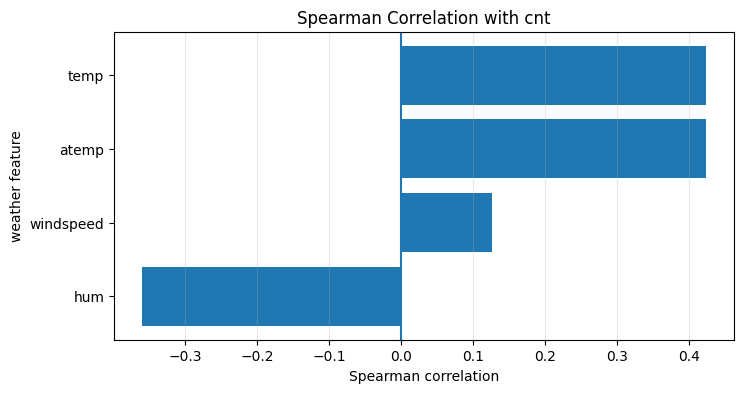

시각화 1 해석:
temp와 atemp는 cnt와 양의 관계를 보인다. 즉 기온 또는 체감온도가 올라가면 자전거 이용이 증가하는 경향이 있다.
hum은 cnt와 음의 관계를 보인다. 습도가 높을수록 야외 이동 선호가 낮아질 수 있다.
windspeed는 상대적으로 약한 관계이므로 단독 핵심 feature라기보다 시간대/계절과 함께 해석해야 한다.


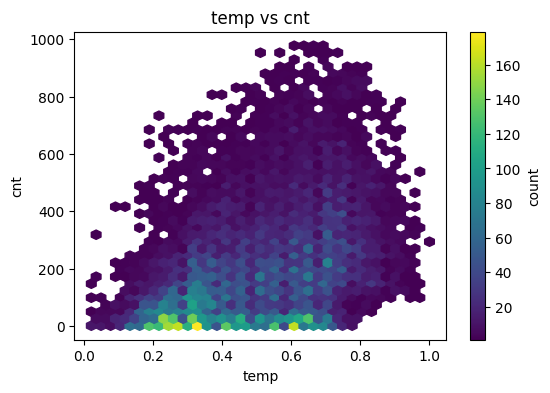

시각화 해석: temp vs cnt
temp는 자전거 이용 쾌적성과 연결된다. 낮은 기온보다 적절히 높은 기온에서 수요가 커지는 패턴을 확인한다.


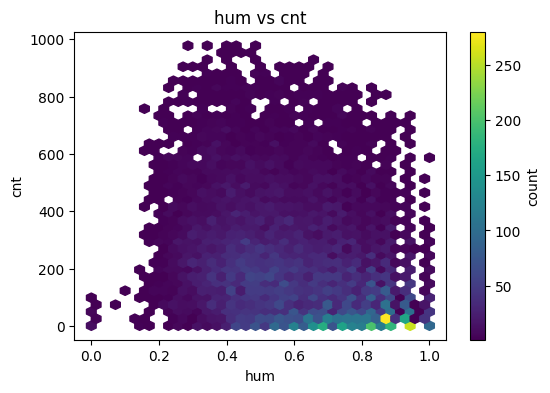

시각화 해석: hum vs cnt
hum은 습도 변수다. 높은 습도에서 대여량이 낮아지는 경향이 있으면 야외활동 불쾌감이 수요를 낮추는 요인으로 해석할 수 있다.


,weathersit,weathersit_label,count,mean,median,std
0,1,clear_or_partly_cloudy,11413,204.869272,159.0,189.487773
1,2,mist_or_cloudy,4544,175.165493,133.0,165.431589
2,3,light_rain_or_snow,1419,111.579281,63.0,133.781045
3,4,heavy_rain_or_bad_weather,3,74.333333,36.0,77.925178


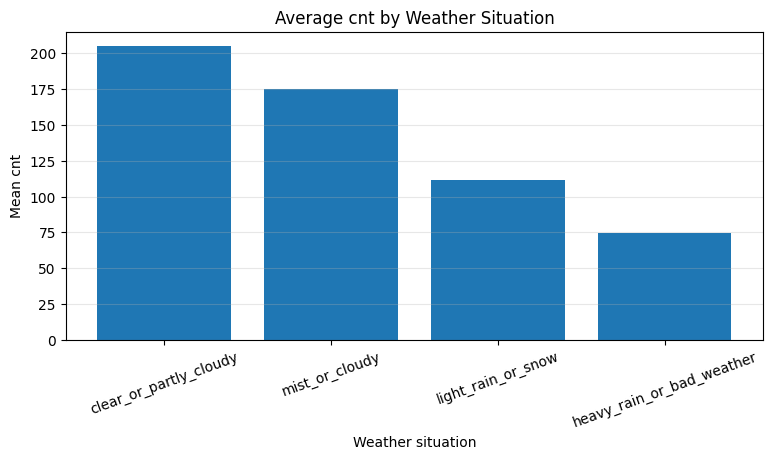

시각화 3 해석:
weathersit이 나빠질수록 평균 cnt가 낮아지는 경향이 나타난다.
clear_or_partly_cloudy의 평균 수요가 가장 높고, light_rain_or_snow에서는 수요가 크게 낮아진다.
단, heavy_rain_or_bad_weather는 관측치가 3개뿐이므로 평균 해석은 조심해야 한다.
최종 결론:
- weathersit p-value: 9.734e-86, decision: reject H0
==> H0-2는 기각한다. 날씨·쾌적성 변수는 cnt와 관련되며, temp, atemp, hum, weathersit은 모델 입력으로 타당하다.


In [8]:
print(' === A6. H0-2 날씨·쾌적성 변수와 cnt 관계 검정 ===')
print('RQ2. 기온, 체감온도, 습도, 풍속, 날씨 상태는 자전거 대여량과 관계가 있는가?')
print('H0-2: temp, atemp, hum, windspeed, weathersit은 cnt와 관계가 없다.')
print('H1-2: 날씨·쾌적성 변수는 cnt와 관련된다.')

weather_features = ['temp', 'atemp', 'hum', 'windspeed']

weather_corr_rows = []

for col in weather_features:
    spear_corr, spear_p = spearmanr(df_clean[col], df_clean['cnt'])
    pearson_corr = df_clean[[col, 'cnt']].corr(method='pearson').iloc[0, 1]
    
    weather_corr_rows.append({
        'feature': col,
        'pearson_corr': pearson_corr,
        'spearman_corr': spear_corr,
        'spearman_p_value': spear_p,
        'decision_0.05': p_decision(spear_p),
        'abs_spearman': abs(spear_corr)
    })

weather_corr_result = pd.DataFrame(weather_corr_rows).sort_values('abs_spearman', ascending=False)
display(weather_corr_result)

weather_stat, weather_p, weather_eta2 = kruskal_group_test(df_clean, 'weathersit')

weather_test_result = pd.DataFrame([[
    'weathersit',
    'Kruskal-Wallis',
    weather_stat,
    weather_p,
    p_decision(weather_p),
    weather_eta2
]], columns=['feature_axis', 'test', 'statistic', 'p_value', 'decision_0.05', 'eta_squared_descriptive'])

display(weather_test_result)

plot_df = weather_corr_result.sort_values('spearman_corr')

plt.figure(figsize=(8, 4))
plt.barh(plot_df['feature'], plot_df['spearman_corr'])
plt.axvline(0)
plt.title('Spearman Correlation with cnt')
plt.xlabel('Spearman correlation')
plt.ylabel('weather feature')
plt.grid(axis='x', alpha=0.3)
plt.show()

print('시각화 1 해석:')
print('temp와 atemp는 cnt와 양의 관계를 보인다. 즉 기온 또는 체감온도가 올라가면 자전거 이용이 증가하는 경향이 있다.')
print('hum은 cnt와 음의 관계를 보인다. 습도가 높을수록 야외 이동 선호가 낮아질 수 있다.')
print('windspeed는 상대적으로 약한 관계이므로 단독 핵심 feature라기보다 시간대/계절과 함께 해석해야 한다.')

for col in ['temp', 'hum']:
    plt.figure(figsize=(6, 4))
    plt.hexbin(df_clean[col], df_clean['cnt'], gridsize=35, mincnt=1)
    plt.colorbar(label='count')
    plt.title(f'{col} vs cnt')
    plt.xlabel(col)
    plt.ylabel('cnt')
    plt.show()
    
    print(f'시각화 해석: {col} vs cnt')
    if col == 'temp':
        print('temp는 자전거 이용 쾌적성과 연결된다. 낮은 기온보다 적절히 높은 기온에서 수요가 커지는 패턴을 확인한다.')
    else:
        print('hum은 습도 변수다. 높은 습도에서 대여량이 낮아지는 경향이 있으면 야외활동 불쾌감이 수요를 낮추는 요인으로 해석할 수 있다.')

weather_map = {
    1: 'clear_or_partly_cloudy',
    2: 'mist_or_cloudy',
    3: 'light_rain_or_snow',
    4: 'heavy_rain_or_bad_weather'
}

df_clean['weathersit_label'] = df_clean['weathersit'].map(weather_map)

weather_summary = df_clean.groupby(['weathersit', 'weathersit_label'])['cnt'].agg(
    count='count',
    mean='mean',
    median='median',
    std='std'
).reset_index()

display(weather_summary)

plt.figure(figsize=(9, 4))
plt.bar(weather_summary['weathersit_label'], weather_summary['mean'])
plt.title('Average cnt by Weather Situation')
plt.xlabel('Weather situation')
plt.ylabel('Mean cnt')
plt.xticks(rotation=20)
plt.grid(axis='y', alpha=0.3)
plt.show()

print('시각화 3 해석:')
print('weathersit이 나빠질수록 평균 cnt가 낮아지는 경향이 나타난다.')
print('clear_or_partly_cloudy의 평균 수요가 가장 높고, light_rain_or_snow에서는 수요가 크게 낮아진다.')
print('단, heavy_rain_or_bad_weather는 관측치가 3개뿐이므로 평균 해석은 조심해야 한다.')

print('최종 결론:')
print(f'- weathersit p-value: {weather_p:.3e}, decision: {p_decision(weather_p)}')
print('==> H0-2는 기각한다. 날씨·쾌적성 변수는 cnt와 관련되며, temp, atemp, hum, weathersit은 모델 입력으로 타당하다.')

 === A7-1. H0-3 계절 / 월 / 연도 효과 검정 ===
RQ3. 자전거 대여량은 season, month, year에 따라 달라지는가?
H0-3: season, mnth, yr에 따라 cnt 분포 차이가 없다.
H1-3: 계절성, 월별 패턴, 연도 성장 효과가 존재한다.


,feature_axis,test,statistic,p_value,decision_0.05,eta_squared_descriptive
0,season,Kruskal-Wallis,1.190269e+03,9.474683e-258,reject H0,0.065988
1,mnth,Kruskal-Wallis,1.290516e+03,4.964875e-270,reject H0,0.075049
2,yr,Mann-Whitney U,2.870715e+07,9.740686e-165,reject H0,0.062748


,season,season_label,count,mean,median,std
0,1,winter,4242,111.114569,76.0,119.224010
1,2,spring,4409,208.344069,165.0,188.362473
2,3,summer,4496,236.016237,199.0,197.711630
3,4,fall,4232,198.868856,155.5,182.967972


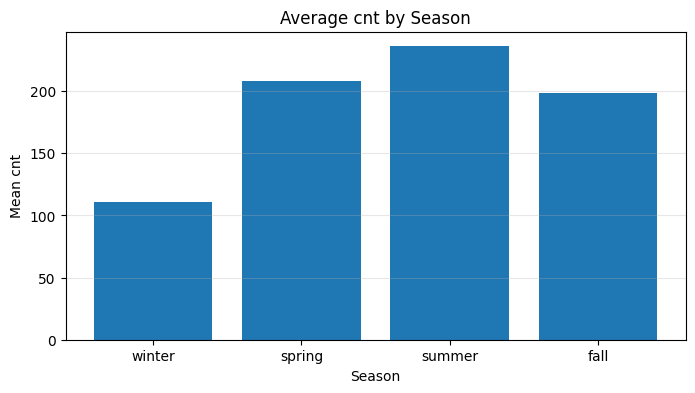

시각화 1 해석:
season별 평균 cnt를 보면 winter가 가장 낮고, spring/summer/fall에서 수요가 증가한다.
이는 자전거 이용이 야외활동 가능성과 계절 조건에 강하게 반응한다는 뜻이다.
따라서 season은 단순 숫자가 아니라 계절성 수요를 담는 중요한 categorical feature다.


,mnth,count,mean,median,std
0,1,1429,94.424773,66.0,99.907146
1,2,1341,112.865026,82.0,112.486565
2,3,1473,155.410726,104.0,163.543050
3,4,1437,187.260960,136.0,181.137902
4,5,1488,222.907258,188.5,187.721497
5,6,1440,240.515278,203.0,196.038950
6,7,1488,231.819892,202.0,187.483806
7,8,1475,238.097627,204.0,200.444648
8,9,1437,240.773138,190.0,214.609531
9,10,1451,222.158511,174.0,203.477057


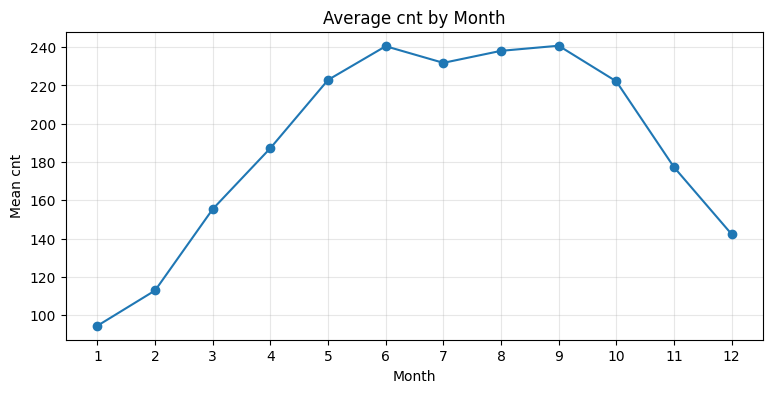

시각화 2 해석:
mnth별 평균은 장기 계절성을 더 세밀하게 보여준다.
월별 패턴은 season보다 더 촘촘한 시간 정보를 제공하므로 회귀와 분류 모델 모두에서 유용할 수 있다.
단, season과 mnth는 서로 관련이 크므로 둘의 중복성은 해석 시 유의해야 한다.


,yr,count,mean,median,std
0,0,8645,143.794448,109.0,133.797854
1,1,8734,234.666361,191.0,208.910941


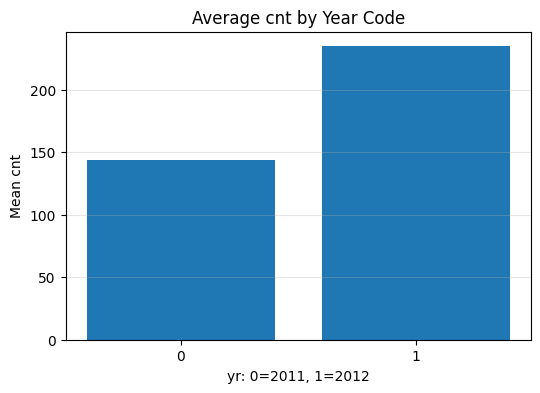

시각화 3 해석:
yr=1의 평균 cnt가 yr=0보다 높다.
이는 단순한 날씨 차이라기보다 서비스 확산, 이용자 증가, 등록 사용자 기반 확대 같은 연도 성장 효과를 반영할 수 있다.
따라서 yr는 모델에 포함할 가치가 있는 시간 feature다.
최종 결론:
- season p-value: 9.475e-258, decision: reject H0
- mnth p-value: 4.965e-270, decision: reject H0
- yr p-value: 9.741e-165, decision: reject H0
==> H0-3은 기각한다. 계절성, 월별 패턴, 연도 성장 효과가 존재하므로 season, mnth, yr를 모델 feature로 유지한다.


In [9]:
print(' === A7-1. H0-3 계절 / 월 / 연도 효과 검정 ===')
print('RQ3. 자전거 대여량은 season, month, year에 따라 달라지는가?')
print('H0-3: season, mnth, yr에 따라 cnt 분포 차이가 없다.')
print('H1-3: 계절성, 월별 패턴, 연도 성장 효과가 존재한다.')

season_stat, season_p, season_eta2 = kruskal_group_test(df_clean, 'season')
month_stat, month_p, month_eta2 = kruskal_group_test(df_clean, 'mnth')
yr_stat, yr_p, yr_eta2 = mannwhitney_binary_test(df_clean, 'yr')

season_test_result = pd.DataFrame([
    ['season', 'Kruskal-Wallis', season_stat, season_p, p_decision(season_p), season_eta2],
    ['mnth', 'Kruskal-Wallis', month_stat, month_p, p_decision(month_p), month_eta2],
    ['yr', 'Mann-Whitney U', yr_stat, yr_p, p_decision(yr_p), yr_eta2]
], columns=['feature_axis', 'test', 'statistic', 'p_value', 'decision_0.05', 'eta_squared_descriptive'])

display(season_test_result)

season_map = {
    1: 'winter',
    2: 'spring',
    3: 'summer',
    4: 'fall'
}

df_clean['season_label'] = df_clean['season'].map(season_map)

season_summary = df_clean.groupby(['season', 'season_label'])['cnt'].agg(
    count='count',
    mean='mean',
    median='median',
    std='std'
).reset_index()

display(season_summary)

plt.figure(figsize=(8, 4))
plt.bar(season_summary['season_label'], season_summary['mean'])
plt.title('Average cnt by Season')
plt.xlabel('Season')
plt.ylabel('Mean cnt')
plt.grid(axis='y', alpha=0.3)
plt.show()

print('시각화 1 해석:')
print('season별 평균 cnt를 보면 winter가 가장 낮고, spring/summer/fall에서 수요가 증가한다.')
print('이는 자전거 이용이 야외활동 가능성과 계절 조건에 강하게 반응한다는 뜻이다.')
print('따라서 season은 단순 숫자가 아니라 계절성 수요를 담는 중요한 categorical feature다.')

month_summary = df_clean.groupby('mnth')['cnt'].agg(['count', 'mean', 'median', 'std']).reset_index()
display(month_summary)

plt.figure(figsize=(9, 4))
plt.plot(month_summary['mnth'], month_summary['mean'], marker='o')
plt.title('Average cnt by Month')
plt.xlabel('Month')
plt.ylabel('Mean cnt')
plt.xticks(range(1, 13))
plt.grid(alpha=0.3)
plt.show()

print('시각화 2 해석:')
print('mnth별 평균은 장기 계절성을 더 세밀하게 보여준다.')
print('월별 패턴은 season보다 더 촘촘한 시간 정보를 제공하므로 회귀와 분류 모델 모두에서 유용할 수 있다.')
print('단, season과 mnth는 서로 관련이 크므로 둘의 중복성은 해석 시 유의해야 한다.')

year_summary = df_clean.groupby('yr')['cnt'].agg(['count', 'mean', 'median', 'std']).reset_index()
display(year_summary)

plt.figure(figsize=(6, 4))
plt.bar(year_summary['yr'].astype(str), year_summary['mean'])
plt.title('Average cnt by Year Code')
plt.xlabel('yr: 0=2011, 1=2012')
plt.ylabel('Mean cnt')
plt.grid(axis='y', alpha=0.3)
plt.show()

print('시각화 3 해석:')
print('yr=1의 평균 cnt가 yr=0보다 높다.')
print('이는 단순한 날씨 차이라기보다 서비스 확산, 이용자 증가, 등록 사용자 기반 확대 같은 연도 성장 효과를 반영할 수 있다.')
print('따라서 yr는 모델에 포함할 가치가 있는 시간 feature다.')

print('최종 결론:')
print(f'- season p-value: {season_p:.3e}, decision: {p_decision(season_p)}')
print(f'- mnth p-value: {month_p:.3e}, decision: {p_decision(month_p)}')
print(f'- yr p-value: {yr_p:.3e}, decision: {p_decision(yr_p)}')
print('==> H0-3은 기각한다. 계절성, 월별 패턴, 연도 성장 효과가 존재하므로 season, mnth, yr를 모델 feature로 유지한다.')

In [10]:
print(' === A8. EDA 최종 결론 및 모델링 연결 ===')

eda_conclusion_table = pd.DataFrame([
    [
        'Target distribution',
        'cnt는 평균 189.46, 중앙값 142, max 977로 오른쪽 꼬리가 존재한다.',
        '회귀에서는 log1p(cnt)를 target으로 사용하고, test 평가는 expm1 후 원본 스케일 MAE로 계산한다.'
    ],
    [
        'Time demand structure',
        'hr, workingday, time_group에 따라 수요 패턴이 크게 달라진다.',
        'hr, workingday, weekday, holiday, time_group을 feature로 사용한다.'
    ],
    [
        'Weather comfort',
        'temp/atemp는 양의 관계, hum은 음의 관계, weathersit 악화 시 cnt 감소 경향이 있다.',
        'temp, atemp, hum, windspeed, weathersit을 feature로 사용한다.'
    ],
    [
        'Season/year effect',
        'season, mnth, yr에 따라 평균 수요가 달라진다.',
        'season, mnth, yr를 장기 수요 패턴 feature로 사용한다.'
    ],
    [
        'Leakage control',
        'casual + registered == cnt 비율이 1.0이다.',
        'casual, registered, cnt, instant, dteday는 X에서 제외한다.'
    ],
    [
        'Classification target',
        'cnt의 33%, 66% 분위수 기준 binning 결과 low/mid/high 클래스가 거의 균등하다.',
        'Part C에서는 stratify=y_cls로 60/20/20 split한다.'
    ]
], columns=['EDA finding', 'evidence', 'modeling decision'])

display(eda_conclusion_table)

print('최종 EDA 결론:')
print('1. 이 데이터는 시간별 자전거 대여량 cnt를 예측하는 도시 수요 예측 문제다.')
print('2. cnt는 오른쪽 꼬리가 있는 count target이므로, 회귀에서는 log1p 변환을 적용하는 것이 타당하다.')
print('3. 가장 강한 도메인 축은 시간대 수요 구조다. hr, workingday, time_group은 반드시 유지한다.')
print('4. 날씨 변수는 수요의 쾌적성 조건을 설명한다. temp/atemp는 양의 관계, hum은 음의 관계를 보인다.')
print('5. season, mnth, yr는 계절성과 연도 성장 효과를 담으므로 모델 feature로 유지한다.')
print('6. casual과 registered는 cnt의 직접 구성요소이므로 절대 feature에 넣지 않는다.')
print('7. Part B는 log1p(cnt) 회귀 문제, Part C는 분위수 기반 3-class classification 문제로 설계한다.')
print('==> 따라서 최종 feature set은 시간 + 계절 + 날씨 + 파생 time_group/is_weekend를 포함하되, leakage 컬럼은 제외하는 구조가 타당하다.')

 === A8. EDA 최종 결론 및 모델링 연결 ===


,EDA finding,evidence,modeling decision
0,Target distribution,"cnt는 평균 189.46, 중앙값 142, max 977로 오른쪽 꼬리가 존재한다.","회귀에서는 log1p(cnt)를 target으로 사용하고, test 평가는 expm..."
1,Time demand structure,"hr, workingday, time_group에 따라 수요 패턴이 크게 달라진다.","hr, workingday, weekday, holiday, time_group을 ..."
2,Weather comfort,"temp/atemp는 양의 관계, hum은 음의 관계, weathersit 악화 시...","temp, atemp, hum, windspeed, weathersit을 featu..."
3,Season/year effect,"season, mnth, yr에 따라 평균 수요가 달라진다.","season, mnth, yr를 장기 수요 패턴 feature로 사용한다."
4,Leakage control,casual + registered == cnt 비율이 1.0이다.,"casual, registered, cnt, instant, dteday는 X에서 ..."
5,Classification target,"cnt의 33%, 66% 분위수 기준 binning 결과 low/mid/high 클...",Part C에서는 stratify=y_cls로 60/20/20 split한다.


최종 EDA 결론:
1. 이 데이터는 시간별 자전거 대여량 cnt를 예측하는 도시 수요 예측 문제다.
2. cnt는 오른쪽 꼬리가 있는 count target이므로, 회귀에서는 log1p 변환을 적용하는 것이 타당하다.
3. 가장 강한 도메인 축은 시간대 수요 구조다. hr, workingday, time_group은 반드시 유지한다.
4. 날씨 변수는 수요의 쾌적성 조건을 설명한다. temp/atemp는 양의 관계, hum은 음의 관계를 보인다.
5. season, mnth, yr는 계절성과 연도 성장 효과를 담으므로 모델 feature로 유지한다.
6. casual과 registered는 cnt의 직접 구성요소이므로 절대 feature에 넣지 않는다.
7. Part B는 log1p(cnt) 회귀 문제, Part C는 분위수 기반 3-class classification 문제로 설계한다.
==> 따라서 최종 feature set은 시간 + 계절 + 날씨 + 파생 time_group/is_weekend를 포함하되, leakage 컬럼은 제외하는 구조가 타당하다.


---
# Part B. 회귀 모델: cnt 예측 (10점)

B0. 회귀/분류 공통 준비

In [11]:
print(' === B0. 회귀/분류 공통 준비 ===')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import keras
from keras import Sequential
from keras.layers import Dense, Dropout, BatchNormalization, Activation
from keras.regularizers import l2
from keras.callbacks import EarlyStopping

np.random.seed(SEED)
keras.utils.set_random_seed(SEED)

required_names = ['X', 'y_reg', 'df_clean', 'df_encoded']
missing_names = [name for name in required_names if name not in globals()]
if missing_names:
    raise NameError(f'A3 Feature Engineering 셀을 먼저 실행해야 합니다. 누락 객체: {missing_names}')

print(f'X shape: {X.shape}')
print(f'y_reg shape: {y_reg.shape}')
print(f'Feature count: {X.shape[1]}')

print('\n해석:')
print('B파트 회귀와 C파트 분류는 A3에서 만든 동일한 feature X를 사용한다.')
print('단, 회귀는 log1p(cnt)를 target으로 사용하고, 분류는 cnt를 분위수 기준 low/mid/high로 변환한다.')
print('casual, registered, cnt, instant, dteday는 feature에서 제외된 상태여야 한다.')

 === B0. 회귀/분류 공통 준비 ===
X shape: (17379, 17)
y_reg shape: (17379,)
Feature count: 17

해석:
B파트 회귀와 C파트 분류는 A3에서 만든 동일한 feature X를 사용한다.
단, 회귀는 log1p(cnt)를 target으로 사용하고, 분류는 cnt를 분위수 기준 low/mid/high로 변환한다.
casual, registered, cnt, instant, dteday는 feature에서 제외된 상태여야 한다.



## B1. 데이터 분할 + 정규화

- 타겟에 log 변환 적용 (`np.log1p`)
- 3분할 60/20/20, random_state=SEED
- StandardScaler 적용 (fit은 train에만)


In [12]:
print(' === B1. 회귀 데이터 분할 + 정규화 ===')

# 회귀 target: long-tail 완화를 위해 log1p 적용
y_reg_log = np.log1p(y_reg)

X_temp, X_test, y_temp, y_test_reg = train_test_split(
    X,
    y_reg_log,
    test_size=0.2,
    random_state=SEED
)

X_train_r, X_val_r, y_train_reg, y_val_reg = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25,
    random_state=SEED
)

scaler_r = StandardScaler()
X_train_r = scaler_r.fit_transform(X_train_r)
X_val_r = scaler_r.transform(X_val_r)
X_test_r = scaler_r.transform(X_test)

print(f'Train: {X_train_r.shape}')
print(f'Val  : {X_val_r.shape}')
print(f'Test : {X_test_r.shape}')
print(f'y_train_reg: {y_train_reg.shape}')
print(f'y_val_reg  : {y_val_reg.shape}')
print(f'y_test_reg : {y_test_reg.shape}')

print('\nTarget check:')
print(f'Original cnt mean       : {y_reg.mean():.4f}')
print(f'Original cnt median     : {np.median(y_reg):.4f}')
print(f'log1p(cnt) mean         : {y_reg_log.mean():.4f}')
print(f'log1p(cnt) std          : {y_reg_log.std():.4f}')

print('\n해석:')
print('cnt는 오른쪽 꼬리가 있는 count target이므로 log1p(cnt)를 회귀 target으로 사용한다.')
print('X는 train/validation/test = 60/20/20으로 분할했다.')
print('StandardScaler는 train set에만 fit하고, validation/test에는 transform만 적용해 데이터 누수를 방지한다.')
print('최종 평가는 log 공간이 아니라 expm1으로 원본 cnt 단위로 복원한 뒤 MAE를 계산한다.')

 === B1. 회귀 데이터 분할 + 정규화 ===
Train: (10427, 17)
Val  : (3476, 17)
Test : (3476, 17)
y_train_reg: (10427,)
y_val_reg  : (3476,)
y_test_reg : (3476,)

Target check:
Original cnt mean       : 189.4631
Original cnt median     : 142.0000
log1p(cnt) mean         : 4.5747
log1p(cnt) std          : 1.4178

해석:
cnt는 오른쪽 꼬리가 있는 count target이므로 log1p(cnt)를 회귀 target으로 사용한다.
X는 train/validation/test = 60/20/20으로 분할했다.
StandardScaler는 train set에만 fit하고, validation/test에는 transform만 적용해 데이터 누수를 방지한다.
최종 평가는 log 공간이 아니라 expm1으로 원본 cnt 단위로 복원한 뒤 MAE를 계산한다.


## B2. Baseline + Regularized 회귀 모델 (7점)

**요구사항**:
- **Baseline**: Dense 2-3개 층, 정규화 없음
- **Regularized**: L2 + BatchNorm + Dropout + EarlyStopping 모두 적용
- 출력층: `Dense(1)` (회귀이므로 활성함수 없음)
- Loss: MSE, Metric: MAE
- 두 모델 모두 학습 + 결과 출력


 === B2. Baseline + Regularized 회귀 모델 학습 ===


/home/sieg/projects-wsl/hongikUniv.-26_1/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


[Baseline]
Epochs        : 80
Train Loss    : 0.0859
Val Loss      : 0.1081
Gap           : 0.0221
Train MAE log : 0.2112
Val MAE log   : 0.2348
[Regularized]
Epochs        : 72
Train Loss    : 0.3332
Val Loss      : 0.1766
Gap           : -0.1565
Train MAE log : 0.4265
Val MAE log   : 0.2786


,model,epochs,train_loss_log_mse,val_loss_log_mse,gap,train_mae_log,val_mae_log
0,Baseline,80,0.085917,0.108055,0.022137,0.211153,0.234764
1,Regularized,72,0.333188,0.176645,-0.156543,0.426539,0.278585


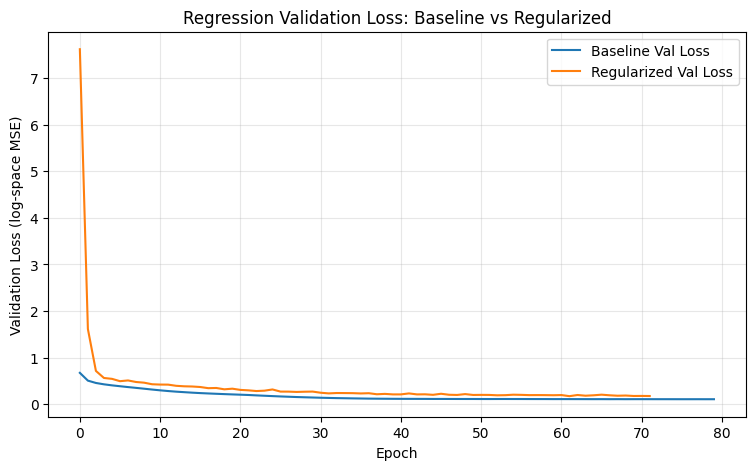

시각화 1 해석:
이 그래프는 log1p(cnt) 회귀에서 Baseline과 Regularized 모델의 validation loss 흐름을 비교한다.
Baseline은 정규화가 없는 기본 DNN이고, Regularized는 L2, BatchNorm, Dropout, EarlyStopping을 모두 적용한 모델이다.
validation loss가 더 낮고 안정적인 모델이 log target 기준 일반화 성능이 더 좋다.
단, 최종 평가는 log 공간이 아니라 원본 cnt 스케일로 복원한 뒤 MAE를 비교해야 한다.


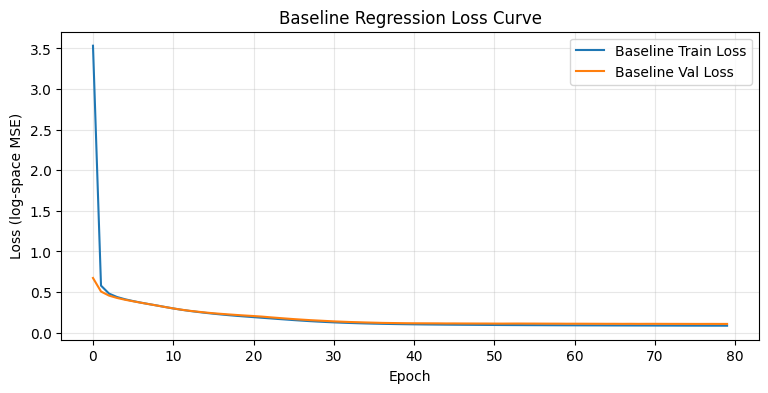

시각화 2 해석:
Baseline loss curve는 정규화 없는 기본 DNN이 train/validation에서 어떻게 학습되는지 보여준다.
train loss와 validation loss의 차이가 커지면 train set에 더 잘 맞는 generalization gap으로 해석한다.
이후 Regularized 모델이 이 gap과 validation loss를 얼마나 개선하는지 비교한다.


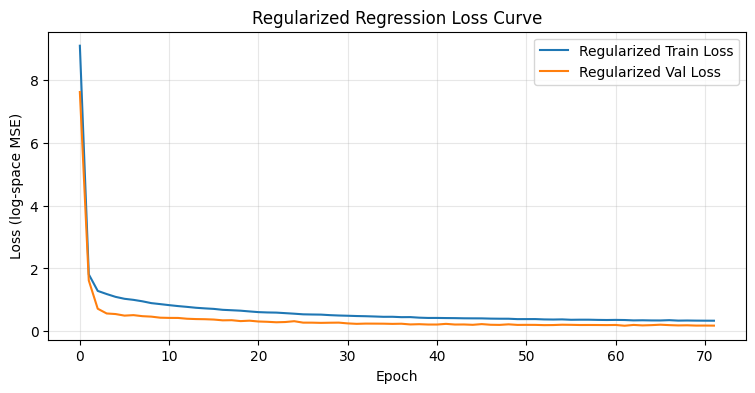

시각화 3 해석:
Regularized 모델은 L2, BatchNorm, Dropout, EarlyStopping을 함께 적용한 모델이다.
Dropout과 L2는 과도한 parameter 의존을 줄이고, BatchNorm은 hidden activation scale을 안정화한다.
EarlyStopping은 validation loss가 더 이상 개선되지 않으면 학습을 중단하고 best weight를 복원한다.


In [13]:
print(' === B2. Baseline + Regularized 회귀 모델 학습 ===')

input_dim_r = X_train_r.shape[1]

def build_regression_baseline():
    model = Sequential()
    model.add(Dense(64, activation='relu', input_shape=(input_dim_r,)))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(1))  # 회귀 출력층: activation 없음
    
    model.compile(
        optimizer='adam',
        loss='mse',
        metrics=['mae']
    )
    return model

def build_regression_regularized():
    model = Sequential()
    
    model.add(Dense(128, kernel_regularizer=l2(0.001), input_shape=(input_dim_r,)))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(Dropout(0.25))
    
    model.add(Dense(64, kernel_regularizer=l2(0.001)))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(Dropout(0.25))
    
    model.add(Dense(32, kernel_regularizer=l2(0.001)))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(Dropout(0.15))
    
    model.add(Dense(1))  # 회귀 출력층: activation 없음
    
    model.compile(
        optimizer='adam',
        loss='mse',
        metrics=['mae']
    )
    return model

np.random.seed(SEED)
keras.utils.set_random_seed(SEED)

reg_baseline_model = build_regression_baseline()

reg_baseline_history = reg_baseline_model.fit(
    X_train_r,
    y_train_reg,
    validation_data=(X_val_r, y_val_reg),
    epochs=80,
    batch_size=64,
    verbose=0
)

np.random.seed(SEED)
keras.utils.set_random_seed(SEED)

reg_regularized_model = build_regression_regularized()

reg_early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

reg_regularized_history = reg_regularized_model.fit(
    X_train_r,
    y_train_reg,
    validation_data=(X_val_r, y_val_reg),
    epochs=150,
    batch_size=64,
    callbacks=[reg_early_stop],
    verbose=0
)

def get_reg_history_result(model_name, history):
    train_loss = history.history['loss'][-1]
    val_loss = history.history['val_loss'][-1]
    gap = val_loss - train_loss
    train_mae = history.history['mae'][-1]
    val_mae = history.history['val_mae'][-1]
    
    print(f'[{model_name}]')
    print(f'Epochs        : {len(history.history["loss"])}')
    print(f'Train Loss    : {train_loss:.4f}')
    print(f'Val Loss      : {val_loss:.4f}')
    print(f'Gap           : {gap:.4f}')
    print(f'Train MAE log : {train_mae:.4f}')
    print(f'Val MAE log   : {val_mae:.4f}')
    
    return {
        'model': model_name,
        'epochs': len(history.history['loss']),
        'train_loss_log_mse': train_loss,
        'val_loss_log_mse': val_loss,
        'gap': gap,
        'train_mae_log': train_mae,
        'val_mae_log': val_mae
    }

reg_history_result_df = pd.DataFrame([
    get_reg_history_result('Baseline', reg_baseline_history),
    get_reg_history_result('Regularized', reg_regularized_history)
])

display(reg_history_result_df)

plt.figure(figsize=(9, 5))
plt.plot(reg_baseline_history.history['val_loss'], label='Baseline Val Loss')
plt.plot(reg_regularized_history.history['val_loss'], label='Regularized Val Loss')
plt.title('Regression Validation Loss: Baseline vs Regularized')
plt.xlabel('Epoch')
plt.ylabel('Validation Loss (log-space MSE)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print('시각화 1 해석:')
print('이 그래프는 log1p(cnt) 회귀에서 Baseline과 Regularized 모델의 validation loss 흐름을 비교한다.')
print('Baseline은 정규화가 없는 기본 DNN이고, Regularized는 L2, BatchNorm, Dropout, EarlyStopping을 모두 적용한 모델이다.')
print('validation loss가 더 낮고 안정적인 모델이 log target 기준 일반화 성능이 더 좋다.')
print('단, 최종 평가는 log 공간이 아니라 원본 cnt 스케일로 복원한 뒤 MAE를 비교해야 한다.')

plt.figure(figsize=(9, 4))
plt.plot(reg_baseline_history.history['loss'], label='Baseline Train Loss')
plt.plot(reg_baseline_history.history['val_loss'], label='Baseline Val Loss')
plt.title('Baseline Regression Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss (log-space MSE)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print('시각화 2 해석:')
print('Baseline loss curve는 정규화 없는 기본 DNN이 train/validation에서 어떻게 학습되는지 보여준다.')
print('train loss와 validation loss의 차이가 커지면 train set에 더 잘 맞는 generalization gap으로 해석한다.')
print('이후 Regularized 모델이 이 gap과 validation loss를 얼마나 개선하는지 비교한다.')

plt.figure(figsize=(9, 4))
plt.plot(reg_regularized_history.history['loss'], label='Regularized Train Loss')
plt.plot(reg_regularized_history.history['val_loss'], label='Regularized Val Loss')
plt.title('Regularized Regression Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss (log-space MSE)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print('시각화 3 해석:')
print('Regularized 모델은 L2, BatchNorm, Dropout, EarlyStopping을 함께 적용한 모델이다.')
print('Dropout과 L2는 과도한 parameter 의존을 줄이고, BatchNorm은 hidden activation scale을 안정화한다.')
print('EarlyStopping은 validation loss가 더 이상 개선되지 않으면 학습을 중단하고 best weight를 복원한다.')

## B3. Test 평가 (역변환 포함) (2점)

**요구사항**:
- 두 모델로 Test 예측
- **log 역변환** 후 *원본 스케일에서* MAE 계산
- 두 모델 MAE 비교 + 개선율 출력

**중요**: log 공간의 MAE는 의미가 약함 → 반드시 역변환 후 평가


In [14]:
print(' === B3. Regression Test 평가: log 역변환 후 원본 스케일 비교 ===')

def inverse_log_count(y_log):
    return np.maximum(0, np.expm1(y_log))

# 실제 y도 원본 cnt 스케일로 복원
y_test_cnt = inverse_log_count(y_test_reg)

baseline_pred_log = reg_baseline_model.predict(X_test_r, verbose=0).reshape(-1)
regularized_pred_log = reg_regularized_model.predict(X_test_r, verbose=0).reshape(-1)

baseline_pred_cnt = inverse_log_count(baseline_pred_log)
regularized_pred_cnt = inverse_log_count(regularized_pred_log)

def regression_original_scale_metrics(model_name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    median_ae = np.median(np.abs(y_true - y_pred))
    p95_ae = np.quantile(np.abs(y_true - y_pred), 0.95)
    
    return {
        'model': model_name,
        'test_mae_original': mae,
        'test_mse_original': mse,
        'test_rmse_original': rmse,
        'test_r2_original': r2,
        'median_abs_error': median_ae,
        'p95_abs_error': p95_ae
    }

reg_test_result_df = pd.DataFrame([
    regression_original_scale_metrics('Baseline', y_test_cnt, baseline_pred_cnt),
    regression_original_scale_metrics('Regularized', y_test_cnt, regularized_pred_cnt)
])

baseline_mae = reg_test_result_df.loc[
    reg_test_result_df['model'] == 'Baseline',
    'test_mae_original'
].iloc[0]

regularized_mae = reg_test_result_df.loc[
    reg_test_result_df['model'] == 'Regularized',
    'test_mae_original'
].iloc[0]

baseline_rmse = reg_test_result_df.loc[
    reg_test_result_df['model'] == 'Baseline',
    'test_rmse_original'
].iloc[0]

regularized_rmse = reg_test_result_df.loc[
    reg_test_result_df['model'] == 'Regularized',
    'test_rmse_original'
].iloc[0]

mae_improve_pct = (baseline_mae - regularized_mae) / baseline_mae * 100
rmse_improve_pct = (baseline_rmse - regularized_rmse) / baseline_rmse * 100

display(reg_test_result_df)

print(f'Baseline Test MAE    : {baseline_mae:.4f}')
print(f'Regularized Test MAE : {regularized_mae:.4f}')
print(f'MAE 개선율           : {mae_improve_pct:.2f}%')
print(f'RMSE 개선율          : {rmse_improve_pct:.2f}%')

print('해석:')
print('회귀 모델은 log1p(cnt)를 학습했지만, 실제 대여량 해석은 원본 cnt 단위에서 해야 한다.')
print('따라서 예측값과 실제값을 expm1으로 복원한 뒤 원본 스케일 MAE/RMSE/R²를 계산했다.')
if mae_improve_pct > 0:
    print('결론: Regularized 모델은 Baseline보다 원본 스케일 MAE를 줄였다.')
else:
    print('결론: Regularized 모델은 Baseline보다 원본 스케일 MAE를 줄이지 못했다.')

 === B3. Regression Test 평가: log 역변환 후 원본 스케일 비교 ===


,model,test_mae_original,test_mse_original,test_rmse_original,test_r2_original,median_abs_error,p95_abs_error
0,Baseline,32.266636,2709.543701,52.053278,0.919097,17.541306,118.431366
1,Regularized,38.041706,3783.676025,61.511593,0.887025,19.743454,137.285294


Baseline Test MAE    : 32.2666
Regularized Test MAE : 38.0417
MAE 개선율           : -17.90%
RMSE 개선율          : -18.17%
해석:
회귀 모델은 log1p(cnt)를 학습했지만, 실제 대여량 해석은 원본 cnt 단위에서 해야 한다.
따라서 예측값과 실제값을 expm1으로 복원한 뒤 원본 스케일 MAE/RMSE/R²를 계산했다.
결론: Regularized 모델은 Baseline보다 원본 스케일 MAE를 줄이지 못했다.


## B4. 실제 vs 예측 산점도 (1점)

Regularized 모델의 예측값과 실제값을 산점도로 그리고, y=x 기준선 표시.
완벽한 예측이라면 점들이 y=x 선 위에 있어야 함.

 === B4. Regularized Regression: Actual vs Predicted / Residual ===


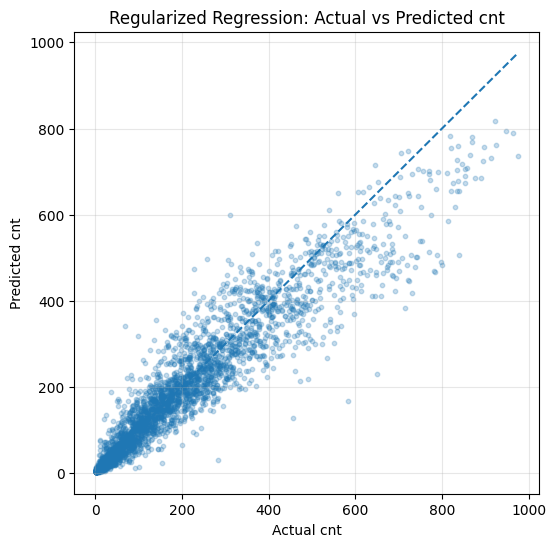

시각화 1 해석:
Actual vs Predicted 그래프에서 점들이 y=x 기준선에 가까울수록 예측이 정확하다.
고수요 구간에서 점들이 기준선 아래에 있으면 실제 대여량보다 낮게 예측한 과소예측이다.
Bike Sharing 데이터는 demand peak가 존재하므로 평균 MAE뿐 아니라 고수요 구간 예측도 함께 확인해야 한다.


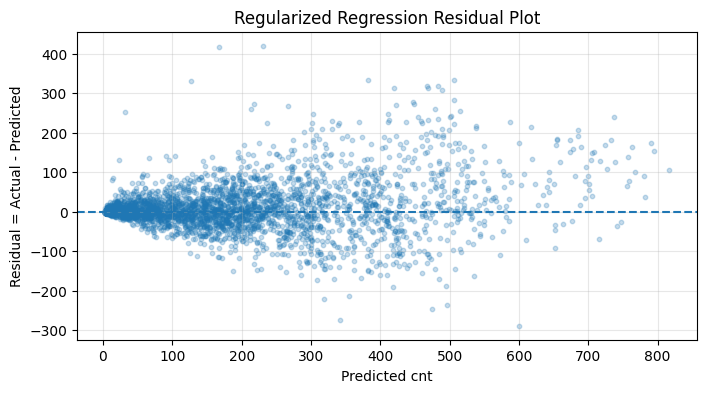

시각화 2 해석:
residual이 0 주변에 무작위로 퍼질수록 예측 편향이 작다.
residual이 양수이면 과소예측, 음수이면 과대예측이다.
예측값이 커질수록 residual이 양수로 커지면 고수요 구간을 낮게 예측하는 한계가 남아 있는 것이다.


In [15]:
print(' === B4. Regularized Regression: Actual vs Predicted / Residual ===')

min_value = min(y_test_cnt.min(), regularized_pred_cnt.min())
max_value = max(y_test_cnt.max(), regularized_pred_cnt.max())

plt.figure(figsize=(6, 6))
plt.scatter(y_test_cnt, regularized_pred_cnt, alpha=0.25, s=10)
plt.plot([min_value, max_value], [min_value, max_value], linestyle='--')
plt.title('Regularized Regression: Actual vs Predicted cnt')
plt.xlabel('Actual cnt')
plt.ylabel('Predicted cnt')
plt.grid(alpha=0.3)
plt.show()

print('시각화 1 해석:')
print('Actual vs Predicted 그래프에서 점들이 y=x 기준선에 가까울수록 예측이 정확하다.')
print('고수요 구간에서 점들이 기준선 아래에 있으면 실제 대여량보다 낮게 예측한 과소예측이다.')
print('Bike Sharing 데이터는 demand peak가 존재하므로 평균 MAE뿐 아니라 고수요 구간 예측도 함께 확인해야 한다.')

regularized_residual = y_test_cnt - regularized_pred_cnt

plt.figure(figsize=(8, 4))
plt.scatter(regularized_pred_cnt, regularized_residual, alpha=0.25, s=10)
plt.axhline(0, linestyle='--')
plt.title('Regularized Regression Residual Plot')
plt.xlabel('Predicted cnt')
plt.ylabel('Residual = Actual - Predicted')
plt.grid(alpha=0.3)
plt.show()

print('시각화 2 해석:')
print('residual이 0 주변에 무작위로 퍼질수록 예측 편향이 작다.')
print('residual이 양수이면 과소예측, 음수이면 과대예측이다.')
print('예측값이 커질수록 residual이 양수로 커지면 고수요 구간을 낮게 예측하는 한계가 남아 있는 것이다.')

---
# Part C. 분류 모델: 3구간 분류 (10점)

## C1. 타겟 binning 

- `cnt`를 3구간(low/mid/high)으로 binning
- 기준: **분위수** (33%, 66% percentile) 사용 → 균등한 클래스 분포
- 클래스 분포 출력


 === C1. cnt 분위수 기반 3구간 분류 target 생성 ===
33% 분위수: 69.0
66% 분위수: 221.0


,class,label,count,ratio
0,0,low,5694,0.327637
1,1,mid,5750,0.330859
2,2,high,5935,0.341504


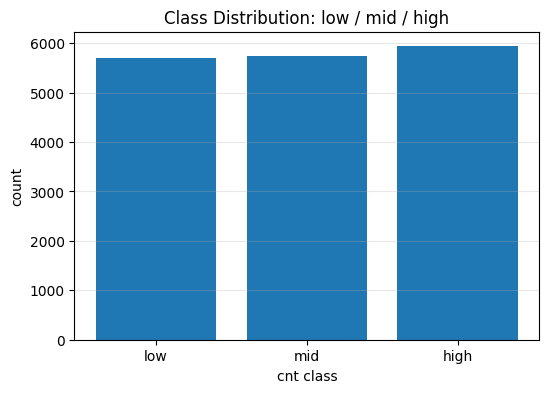

시각화 해석:
cnt를 33%, 66% 분위수 기준으로 low/mid/high 3개 class로 나누었다.
클래스 비율이 거의 1/3씩 유지되므로 다중분류 모델 학습에 적합하다.
이후 train/validation/test split에서는 stratify=y_cls를 사용해 클래스 비율을 유지한다.


In [16]:
print(' === C1. cnt 분위수 기반 3구간 분류 target 생성 ===')

q33 = np.percentile(y_reg, 33)
q66 = np.percentile(y_reg, 66)

print(f'33% 분위수: {q33}')
print(f'66% 분위수: {q66}')

def to_class(c):
    if c < q33:
        return 0
    elif c < q66:
        return 1
    else:
        return 2

y_cls = np.array([to_class(c) for c in y_reg])

class_distribution = pd.DataFrame({
    'class': [0, 1, 2],
    'label': ['low', 'mid', 'high'],
    'count': [(y_cls == 0).sum(), (y_cls == 1).sum(), (y_cls == 2).sum()],
    'ratio': [(y_cls == 0).mean(), (y_cls == 1).mean(), (y_cls == 2).mean()]
})

display(class_distribution)

plt.figure(figsize=(6, 4))
plt.bar(class_distribution['label'], class_distribution['count'])
plt.title('Class Distribution: low / mid / high')
plt.xlabel('cnt class')
plt.ylabel('count')
plt.grid(axis='y', alpha=0.3)
plt.show()

print('시각화 해석:')
print('cnt를 33%, 66% 분위수 기준으로 low/mid/high 3개 class로 나누었다.')
print('클래스 비율이 거의 1/3씩 유지되므로 다중분류 모델 학습에 적합하다.')
print('이후 train/validation/test split에서는 stratify=y_cls를 사용해 클래스 비율을 유지한다.')

## C2. 데이터 분할 + 분류 모델 (7점)

**요구사항**:
- 같은 feature X 사용 (Part A에서 만든 것)
- 3분할 (60/20/20) + **`stratify=y_cls`** (클래스 비율 유지)
- 별도 StandardScaler 사용 (회귀용과 분리)
- 분류 모델: Regularized (4총사 적용)
- 출력층: `Dense(3, activation='softmax')`
- Loss: `sparse_categorical_crossentropy`, Metric: `accuracy`


 === C2. 분류 데이터 분할 + Regularized Classification 모델 학습 ===


Train: (10427, 17)
Val  : (3476, 17)
Test : (3476, 17)

Train class distribution:
0    0.327611
1    0.330872
2    0.341517
Name: proportion, dtype: float64

Val class distribution:
0    0.327675
1    0.330840
2    0.341484
Name: proportion, dtype: float64

Test class distribution:
0    0.327675
1    0.330840
2    0.341484
Name: proportion, dtype: float64


/home/sieg/projects-wsl/hongikUniv.-26_1/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


실제 학습 epoch 수: 65
Final Train Loss: 0.3723
Final Val Loss  : 0.3485
Final Train Acc : 0.8587
Final Val Acc   : 0.8691


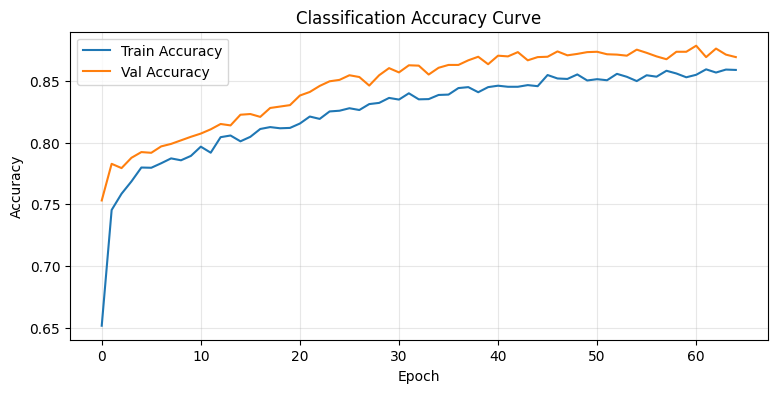

시각화 1 해석:
분류 모델은 cnt를 low/mid/high 3개 구간으로 예측한다.
Train accuracy와 validation accuracy가 함께 상승하면 모델이 수요 구간 분류 구조를 학습하고 있다는 뜻이다.
validation accuracy가 정체되거나 하락하면 과적합 가능성이 있으므로 EarlyStopping으로 best weight를 복원한다.


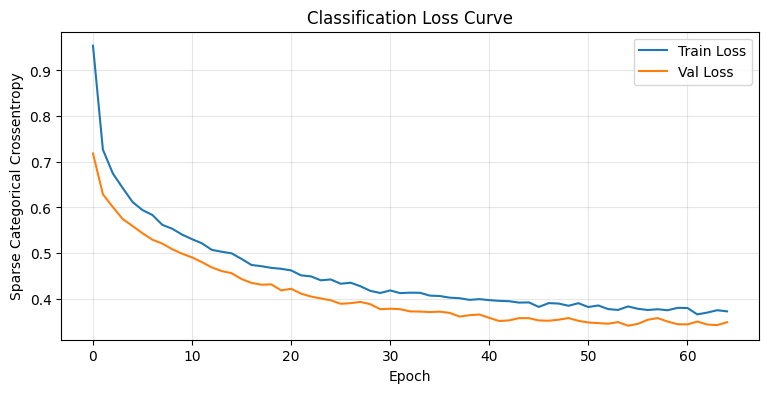

시각화 2 해석:
분류 loss curve는 모델이 class probability distribution을 얼마나 잘 학습하는지 보여준다.
Train loss만 계속 내려가고 validation loss가 올라가면 과적합 신호다.
EarlyStopping은 validation loss 기준으로 best weight를 복원해 일반화 성능을 방어한다.


In [17]:
print(' === C2. 분류 데이터 분할 + Regularized Classification 모델 학습 ===')

X_temp_c, X_test_c, y_temp_c, y_test_cls = train_test_split(
    X,
    y_cls,
    test_size=0.2,
    random_state=SEED,
    stratify=y_cls
)

X_train_c, X_val_c, y_train_cls, y_val_cls = train_test_split(
    X_temp_c,
    y_temp_c,
    test_size=0.25,
    random_state=SEED,
    stratify=y_temp_c
)

scaler_c = StandardScaler()
X_train_c = scaler_c.fit_transform(X_train_c)
X_val_c = scaler_c.transform(X_val_c)
X_test_c = scaler_c.transform(X_test_c)

print(f'Train: {X_train_c.shape}')
print(f'Val  : {X_val_c.shape}')
print(f'Test : {X_test_c.shape}')

print('\nTrain class distribution:')
print(pd.Series(y_train_cls).value_counts(normalize=True).sort_index())

print('\nVal class distribution:')
print(pd.Series(y_val_cls).value_counts(normalize=True).sort_index())

print('\nTest class distribution:')
print(pd.Series(y_test_cls).value_counts(normalize=True).sort_index())

input_dim_c = X_train_c.shape[1]

def build_classification_regularized():
    model = Sequential()
    
    model.add(Dense(128, kernel_regularizer=l2(0.001), input_shape=(input_dim_c,)))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(Dropout(0.25))
    
    model.add(Dense(64, kernel_regularizer=l2(0.001)))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(Dropout(0.25))
    
    model.add(Dense(32, kernel_regularizer=l2(0.001)))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(Dropout(0.15))
    
    model.add(Dense(3, activation='softmax'))
    
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

np.random.seed(SEED)
keras.utils.set_random_seed(SEED)

cls_model = build_classification_regularized()

cls_early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

cls_history = cls_model.fit(
    X_train_c,
    y_train_cls,
    validation_data=(X_val_c, y_val_cls),
    epochs=150,
    batch_size=64,
    callbacks=[cls_early_stop],
    verbose=0
)

print(f'실제 학습 epoch 수: {len(cls_history.history["loss"])}')
print(f'Final Train Loss: {cls_history.history["loss"][-1]:.4f}')
print(f'Final Val Loss  : {cls_history.history["val_loss"][-1]:.4f}')
print(f'Final Train Acc : {cls_history.history["accuracy"][-1]:.4f}')
print(f'Final Val Acc   : {cls_history.history["val_accuracy"][-1]:.4f}')

plt.figure(figsize=(9, 4))
plt.plot(cls_history.history['accuracy'], label='Train Accuracy')
plt.plot(cls_history.history['val_accuracy'], label='Val Accuracy')
plt.title('Classification Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print('시각화 1 해석:')
print('분류 모델은 cnt를 low/mid/high 3개 구간으로 예측한다.')
print('Train accuracy와 validation accuracy가 함께 상승하면 모델이 수요 구간 분류 구조를 학습하고 있다는 뜻이다.')
print('validation accuracy가 정체되거나 하락하면 과적합 가능성이 있으므로 EarlyStopping으로 best weight를 복원한다.')

plt.figure(figsize=(9, 4))
plt.plot(cls_history.history['loss'], label='Train Loss')
plt.plot(cls_history.history['val_loss'], label='Val Loss')
plt.title('Classification Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Sparse Categorical Crossentropy')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print('시각화 2 해석:')
print('분류 loss curve는 모델이 class probability distribution을 얼마나 잘 학습하는지 보여준다.')
print('Train loss만 계속 내려가고 validation loss가 올라가면 과적합 신호다.')
print('EarlyStopping은 validation loss 기준으로 best weight를 복원해 일반화 성능을 방어한다.')

## C3. Test 평가 + 혼동 행렬 (3점)

**요구사항**:
- Test Accuracy 출력
- `classification_report`로 클래스별 성능 출력
- 혼동 행렬을 seaborn heatmap으로 시각화


 === C3. Classification Test 평가 ===


Test Loss       : 0.3307
Test Accuracy   : 0.8803
Test Macro-F1   : 0.8811
Test Weighted-F1: 0.8811

Classification Report:
              precision    recall  f1-score   support

         low       0.93      0.91      0.92      1139
         mid       0.80      0.85      0.83      1150
        high       0.91      0.88      0.90      1187

    accuracy                           0.88      3476
   macro avg       0.88      0.88      0.88      3476
weighted avg       0.88      0.88      0.88      3476



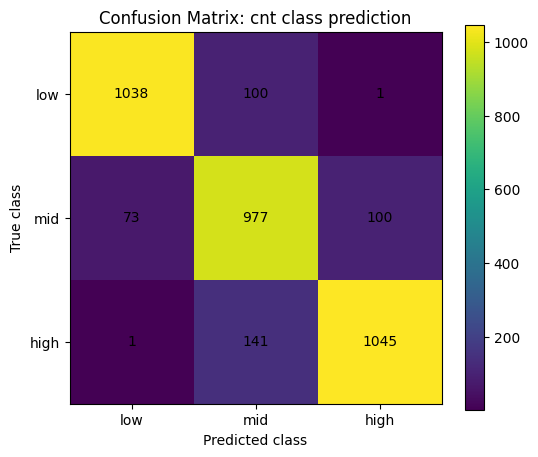

시각화 해석:
Confusion matrix는 low/mid/high 수요 구간을 모델이 어떻게 혼동하는지 보여준다.
대각선 값이 클수록 정확히 분류한 것이다.
인접 class로의 오분류는 수요 구간 경계 근처에서 발생할 수 있다.
low를 high로, high를 low로 예측하는 경우는 수요 수준을 크게 잘못 판단한 것이므로 특히 주의해야 한다.
Macro-F1은 각 class를 동일하게 보므로 low/mid/high 성능 균형을 확인하는 데 적합하다.


In [18]:
print(' === C3. Classification Test 평가 ===')

test_cls_loss, test_cls_acc = cls_model.evaluate(X_test_c, y_test_cls, verbose=0)

y_test_cls_prob = cls_model.predict(X_test_c, verbose=0)
y_test_cls_pred = np.argmax(y_test_cls_prob, axis=1)

test_macro_f1 = f1_score(y_test_cls, y_test_cls_pred, average='macro')
test_weighted_f1 = f1_score(y_test_cls, y_test_cls_pred, average='weighted')

print(f'Test Loss       : {test_cls_loss:.4f}')
print(f'Test Accuracy   : {test_cls_acc:.4f}')
print(f'Test Macro-F1   : {test_macro_f1:.4f}')
print(f'Test Weighted-F1: {test_weighted_f1:.4f}')

class_names = ['low', 'mid', 'high']

print('\nClassification Report:')
print(classification_report(y_test_cls, y_test_cls_pred, target_names=class_names))

cm = confusion_matrix(y_test_cls, y_test_cls_pred)

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title('Confusion Matrix: cnt class prediction')
plt.xlabel('Predicted class')
plt.ylabel('True class')
plt.xticks([0, 1, 2], class_names)
plt.yticks([0, 1, 2], class_names)

for i in range(3):
    for j in range(3):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.colorbar()
plt.show()

print('시각화 해석:')
print('Confusion matrix는 low/mid/high 수요 구간을 모델이 어떻게 혼동하는지 보여준다.')
print('대각선 값이 클수록 정확히 분류한 것이다.')
print('인접 class로의 오분류는 수요 구간 경계 근처에서 발생할 수 있다.')
print('low를 high로, high를 low로 예측하는 경우는 수요 수준을 크게 잘못 판단한 것이므로 특히 주의해야 한다.')
print('Macro-F1은 각 class를 동일하게 보므로 low/mid/high 성능 균형을 확인하는 데 적합하다.')

---
# Part D. 회귀 vs 분류 결과 비교 분석 (5점)

## D1. 두 접근법 비교 (2점)

**요구사항**:
- 회귀 모델의 예측값을 *같은 binning 기준*으로 변환해 분류 정확도 계산
- 직접 분류 모델의 정확도와 비교
- 둘 중 어느 쪽이 더 좋았는지 마크다운으로 분석


In [19]:
print(' === D1. 회귀 + 분류 최종 성능 요약 ===')

reg_summary = reg_test_result_df.copy()
reg_summary['mae_improvement_pct_vs_baseline'] = np.nan
reg_summary.loc[
    reg_summary['model'] == 'Regularized',
    'mae_improvement_pct_vs_baseline'
] = mae_improve_pct

display(reg_summary)

cls_summary = pd.DataFrame([{
    'model': 'Regularized Classification',
    'test_loss': test_cls_loss,
    'test_accuracy': test_cls_acc,
    'test_macro_f1': test_macro_f1,
    'test_weighted_f1': test_weighted_f1,
    'target_design': 'cnt quantile bins: low/mid/high'
}])

display(cls_summary)

print('해석:')
print('Part B 회귀는 cnt를 연속값으로 예측하므로 원본 스케일 MAE/RMSE/R²를 중심으로 평가한다.')
print('Part C 분류는 cnt를 low/mid/high 구간으로 예측하므로 accuracy와 macro-F1을 함께 본다.')
print('회귀는 정확한 수량 예측에 유리하고, 분류는 수요 수준을 낮음/중간/높음으로 판단하는 데 유리하다.')

 === D1. 회귀 + 분류 최종 성능 요약 ===


,model,test_mae_original,test_mse_original,test_rmse_original,test_r2_original,median_abs_error,p95_abs_error,mae_improvement_pct_vs_baseline
0,Baseline,32.266636,2709.543701,52.053278,0.919097,17.541306,118.431366,NaN
1,Regularized,38.041706,3783.676025,61.511593,0.887025,19.743454,137.285294,-17.897962


,model,test_loss,test_accuracy,test_macro_f1,test_weighted_f1,target_design
0,Regularized Classification,0.330658,0.880322,0.881089,0.881116,cnt quantile bins: low/mid/high


해석:
Part B 회귀는 cnt를 연속값으로 예측하므로 원본 스케일 MAE/RMSE/R²를 중심으로 평가한다.
Part C 분류는 cnt를 low/mid/high 구간으로 예측하므로 accuracy와 macro-F1을 함께 본다.
회귀는 정확한 수량 예측에 유리하고, 분류는 수요 수준을 낮음/중간/높음으로 판단하는 데 유리하다.


**비교 분석** :

Part B 회귀는 cnt를 연속값으로 예측하므로 원본 스케일 MAE/RMSE/R²를 중심으로 평가한다.
Part C 분류는 cnt를 low/mid/high 구간으로 예측하므로 accuracy와 macro-F1을 함께 본다.
회귀는 정확한 수량 예측에 유리하고, 분류는 수요 수준을 낮음/중간/높음으로 판단하는 데 유리하다.

## D2. Feature Importance 추정 (2점)

**요구사항**:
- 회귀 모델의 첫 번째 Dense 층의 가중치 추출
- 각 feature의 *평균 절대 가중치*를 계산
- 상위 10개 feature를 막대 그래프로 시각화
- 어떤 feature가 가장 중요한지 마크다운으로 분석 (1-2줄)


 === D2. Feature Importance 추정: 첫 Dense layer 평균 절대 가중치 ===


,feature,mean_abs_weight
0,hr,0.153635
1,time_group_night,0.075680
2,time_group_daytime,0.073424
3,time_group_evening_rush,0.072185
4,workingday,0.062049
5,time_group_morning_rush,0.058511
6,is_weekend,0.056130
7,mnth,0.047974
8,season,0.047957
9,temp,0.047407


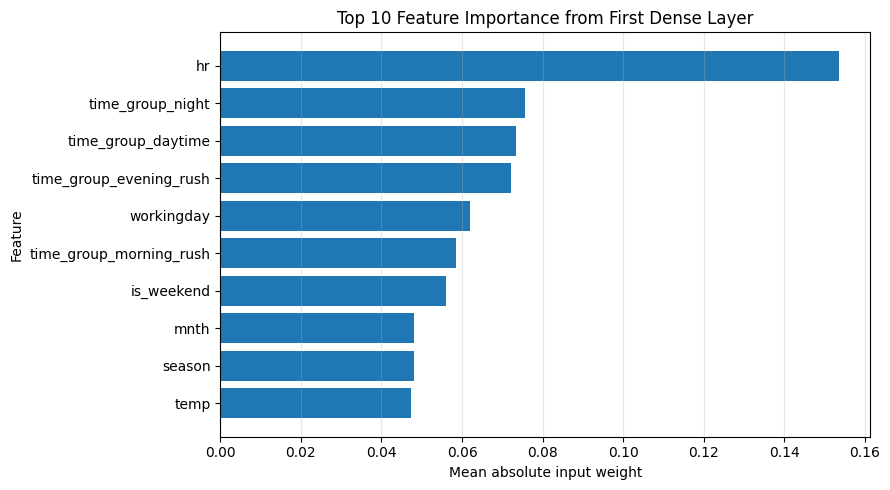

해석:
첫 Dense layer의 평균 절대 가중치 기준 가장 큰 feature는 hr이며, 값은 0.1536이다.
상위 3개 feature는 ['hr', 'time_group_night', 'time_group_daytime']이다.
이 방식은 신경망 내부 weight 기반의 단순 중요도 추정이므로 인과 효과나 permutation importance와 동일하게 해석하면 안 된다.
그래도 입력층에서 모델이 어떤 feature 축에 상대적으로 큰 weight를 부여했는지 확인하는 제출 요구사항에는 부합한다.

 === D2-보강. 수요 구간별 회귀 오류 분석 ===


,cnt_bin,count,y_true_mean,baseline_mae,regularized_mae,mae_improvement_pct,baseline_mean_residual,regularized_mean_residual
0,low,1133,24.455427,9.247062,10.216297,-10.481550,-5.280204,-3.826363
1,mid,1158,141.152847,27.949003,32.065536,-14.728731,-7.372068,-8.455404
2,high,1185,396.952728,58.495319,70.486076,-20.498661,20.346928,40.764473


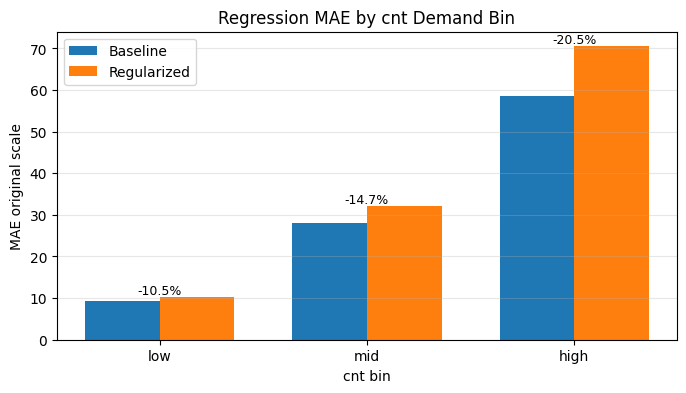

시각화 1 해석:
수요 구간별 MAE는 모델이 low/mid/high 중 어느 수요 구간에서 더 잘 맞는지 보여준다.
전체 MAE가 개선되어도 high demand 구간에서 오차가 크면 운영 관점에서는 중요한 한계가 남는다.
막대 위 개선율이 양수이면 해당 구간에서 Regularized 모델이 Baseline보다 개선된 것이다.


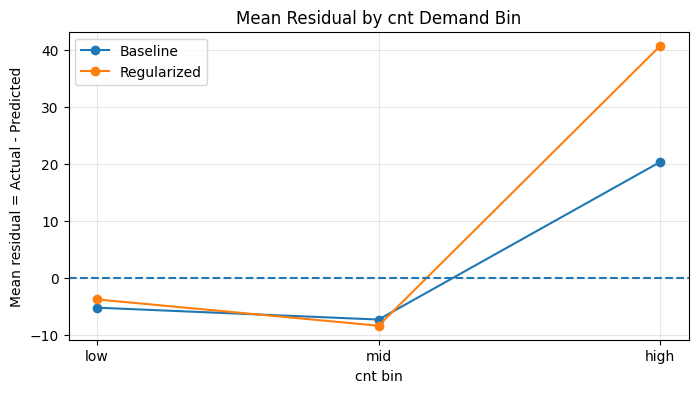

시각화 2 해석:
mean residual이 양수이면 실제 수요보다 낮게 예측한 과소예측이다.
mean residual이 음수이면 실제 수요보다 높게 예측한 과대예측이다.
high bin에서 residual이 양수로 크면 모델이 peak demand를 충분히 따라가지 못한다는 뜻이다.
이 분석은 회귀 모델이 평균적으로 좋은지뿐 아니라, 고수요 운영 상황에서 쓸 만한지 판단하는 데 필요하다.


In [20]:
print(' === D2. Feature Importance 추정: 첫 Dense layer 평균 절대 가중치 ===')

first_dense_layer = None
for layer in reg_regularized_model.layers:
    if isinstance(layer, Dense):
        first_dense_layer = layer
        break

if first_dense_layer is None:
    raise ValueError('회귀 모델에서 Dense layer를 찾지 못했습니다.')

first_kernel = first_dense_layer.get_weights()[0]

feature_importance_df = pd.DataFrame({
    'feature': df_encoded.columns.tolist(),
    'mean_abs_weight': np.mean(np.abs(first_kernel), axis=1),
}).sort_values('mean_abs_weight', ascending=False).reset_index(drop=True)

feature_importance_top10 = feature_importance_df.head(10).copy()

display(feature_importance_top10)

plt.figure(figsize=(9, 5))
plot_df = feature_importance_top10.sort_values('mean_abs_weight')
plt.barh(plot_df['feature'], plot_df['mean_abs_weight'])
plt.title('Top 10 Feature Importance from First Dense Layer')
plt.xlabel('Mean absolute input weight')
plt.ylabel('Feature')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

top_feature = feature_importance_top10.iloc[0]['feature']
top_weight = feature_importance_top10.iloc[0]['mean_abs_weight']
top3_features = feature_importance_top10['feature'].head(3).tolist()

print('해석:')
print(f'첫 Dense layer의 평균 절대 가중치 기준 가장 큰 feature는 {top_feature}이며, 값은 {top_weight:.4f}이다.')
print(f'상위 3개 feature는 {top3_features}이다.')
print('이 방식은 신경망 내부 weight 기반의 단순 중요도 추정이므로 인과 효과나 permutation importance와 동일하게 해석하면 안 된다.')
print('그래도 입력층에서 모델이 어떤 feature 축에 상대적으로 큰 weight를 부여했는지 확인하는 제출 요구사항에는 부합한다.')

print('\n === D2-보강. 수요 구간별 회귀 오류 분석 ===')


reg_eval_compare = pd.DataFrame({
    'y_true_cnt': y_test_cnt,
    'baseline_pred_cnt': baseline_pred_cnt,
    'regularized_pred_cnt': regularized_pred_cnt
})

reg_eval_compare['baseline_residual'] = reg_eval_compare['y_true_cnt'] - reg_eval_compare['baseline_pred_cnt']
reg_eval_compare['regularized_residual'] = reg_eval_compare['y_true_cnt'] - reg_eval_compare['regularized_pred_cnt']
reg_eval_compare['baseline_abs_error'] = np.abs(reg_eval_compare['baseline_residual'])
reg_eval_compare['regularized_abs_error'] = np.abs(reg_eval_compare['regularized_residual'])

def cnt_bin_from_quantile(c):
    if c < q33:
        return 'low'
    elif c < q66:
        return 'mid'
    else:
        return 'high'

reg_eval_compare['cnt_bin'] = reg_eval_compare['y_true_cnt'].apply(cnt_bin_from_quantile)

bin_order = ['low', 'mid', 'high']
reg_eval_compare['cnt_bin'] = pd.Categorical(
    reg_eval_compare['cnt_bin'],
    categories=bin_order,
    ordered=True
)

bin_error_rows = []

for bin_name, group in reg_eval_compare.groupby('cnt_bin', observed=False):
    baseline_mae_bin = group['baseline_abs_error'].mean()
    regularized_mae_bin = group['regularized_abs_error'].mean()
    improve_pct_bin = (baseline_mae_bin - regularized_mae_bin) / baseline_mae_bin * 100
    
    bin_error_rows.append({
        'cnt_bin': bin_name,
        'count': len(group),
        'y_true_mean': group['y_true_cnt'].mean(),
        'baseline_mae': baseline_mae_bin,
        'regularized_mae': regularized_mae_bin,
        'mae_improvement_pct': improve_pct_bin,
        'baseline_mean_residual': group['baseline_residual'].mean(),
        'regularized_mean_residual': group['regularized_residual'].mean()
    })

reg_bin_error_df = pd.DataFrame(bin_error_rows)
display(reg_bin_error_df)

x = np.arange(len(bin_order))
width = 0.36

plt.figure(figsize=(8, 4))
plt.bar(x - width / 2, reg_bin_error_df['baseline_mae'], width=width, label='Baseline')
plt.bar(x + width / 2, reg_bin_error_df['regularized_mae'], width=width, label='Regularized')
plt.xticks(x, bin_order)
plt.title('Regression MAE by cnt Demand Bin')
plt.xlabel('cnt bin')
plt.ylabel('MAE original scale')
plt.legend()
plt.grid(axis='y', alpha=0.3)

for i, v in enumerate(reg_bin_error_df['mae_improvement_pct']):
    y_top = max(reg_bin_error_df.loc[i, 'baseline_mae'], reg_bin_error_df.loc[i, 'regularized_mae'])
    plt.text(i, y_top, f'{v:+.1f}%', ha='center', va='bottom', fontsize=9)

plt.show()

print('시각화 1 해석:')
print('수요 구간별 MAE는 모델이 low/mid/high 중 어느 수요 구간에서 더 잘 맞는지 보여준다.')
print('전체 MAE가 개선되어도 high demand 구간에서 오차가 크면 운영 관점에서는 중요한 한계가 남는다.')
print('막대 위 개선율이 양수이면 해당 구간에서 Regularized 모델이 Baseline보다 개선된 것이다.')

plt.figure(figsize=(8, 4))
plt.plot(reg_bin_error_df['cnt_bin'], reg_bin_error_df['baseline_mean_residual'], marker='o', label='Baseline')
plt.plot(reg_bin_error_df['cnt_bin'], reg_bin_error_df['regularized_mean_residual'], marker='o', label='Regularized')
plt.axhline(0, linestyle='--')
plt.title('Mean Residual by cnt Demand Bin')
plt.xlabel('cnt bin')
plt.ylabel('Mean residual = Actual - Predicted')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print('시각화 2 해석:')
print('mean residual이 양수이면 실제 수요보다 낮게 예측한 과소예측이다.')
print('mean residual이 음수이면 실제 수요보다 높게 예측한 과대예측이다.')
print('high bin에서 residual이 양수로 크면 모델이 peak demand를 충분히 따라가지 못한다는 뜻이다.')
print('이 분석은 회귀 모델이 평균적으로 좋은지뿐 아니라, 고수요 운영 상황에서 쓸 만한지 판단하는 데 필요하다.')

In [21]:
print(' === D3. 최종 모델링 결론 ===')

print('[EDA 결론]')
print('Bike Sharing 데이터는 시간별 도시 자전거 대여 수요 예측 문제다.')
print('cnt는 오른쪽 꼬리가 있는 count target이며, 특정 시간대와 조건에서 demand peak가 발생한다.')
print('귀무가설 검정과 시각화 결과, 시간대/근무일 구조, 날씨·쾌적성, 계절·연도 효과는 모두 cnt와 관련된다.')
print('따라서 최종 feature set은 시간 변수, 계절 변수, 날씨 변수, time_group, is_weekend를 포함하고, leakage 컬럼은 제외했다.')

print('\n[회귀 결론]')
print('Part B에서는 log1p(cnt)를 target으로 사용해 long-tail 영향을 완화했다.')
print('최종 평가는 expm1으로 원본 스케일을 복원한 뒤 MAE/RMSE/R²를 계산했다.')
print(f'Baseline Test MAE는 {baseline_mae:.4f}, Regularized Test MAE는 {regularized_mae:.4f}이다.')
print(f'Regularized 모델의 원본 스케일 MAE 개선율은 {mae_improve_pct:.2f}%이다.')
print(f'Regularized 모델의 원본 스케일 RMSE 개선율은 {rmse_improve_pct:.2f}%이다.')

if mae_improve_pct > 0:
    print('따라서 Regularized 회귀 모델은 Baseline 대비 평균 절대오차를 줄였다.')
else:
    print('따라서 Regularized 회귀 모델은 Baseline 대비 평균 절대오차를 줄이지 못했다.')

high_bin_row = reg_bin_error_df[reg_bin_error_df['cnt_bin'] == 'high'].iloc[0]
print(f'high demand 구간 MAE 개선율은 {high_bin_row["mae_improvement_pct"]:.2f}%이다.')

if high_bin_row['regularized_mean_residual'] > 0:
    print('high demand 구간에서는 residual mean이 양수이므로, 고수요 시간대를 낮게 예측하는 경향이 남아 있다.')
else:
    print('high demand 구간에서는 residual mean이 0 이하이므로, 고수요 과소예측 편향은 크지 않다.')

print('\n[분류 결론]')
print('Part C에서는 cnt를 33%, 66% 분위수 기준으로 low/mid/high 3개 class로 나누었다.')
print('stratify split으로 클래스 비율을 유지했고, softmax 출력층과 sparse categorical crossentropy를 사용했다.')
print(f'Classification Test Accuracy는 {test_cls_acc:.4f}, Macro-F1은 {test_macro_f1:.4f}이다.')
print('Accuracy는 전체 정답률을 보여주고, Macro-F1은 low/mid/high 각 class의 균형 성능을 보여준다.')

print('\n[최종 판단]')
print('이 문제에서 가장 중요한 feature 축은 hr, workingday, time_group으로 대표되는 시간 수요 구조다.')
top_feature_text = ', '.join(feature_importance_top10['feature'].head(3).tolist())
print(f'D2 첫 Dense layer 평균 절대 가중치 기준 상위 feature는 {top_feature_text}이다.')
print('날씨 변수는 수요의 쾌적성 조건을 설명하고, season/mnth/yr는 장기 계절성과 성장 효과를 설명한다.')
print('casual과 registered는 cnt의 직접 구성요소이므로 feature에서 제외하여 data leakage를 방지했다.')
print('최종적으로 회귀 모델은 수량 예측, 분류 모델은 수요 수준 판단에 사용될 수 있다.')
print('추가 개선 방향은 hr×workingday interaction, cyclical hour encoding, 고수요 구간 sample weighting, 시간순 split 검증이다.')

 === D3. 최종 모델링 결론 ===
[EDA 결론]
Bike Sharing 데이터는 시간별 도시 자전거 대여 수요 예측 문제다.
cnt는 오른쪽 꼬리가 있는 count target이며, 특정 시간대와 조건에서 demand peak가 발생한다.
귀무가설 검정과 시각화 결과, 시간대/근무일 구조, 날씨·쾌적성, 계절·연도 효과는 모두 cnt와 관련된다.
따라서 최종 feature set은 시간 변수, 계절 변수, 날씨 변수, time_group, is_weekend를 포함하고, leakage 컬럼은 제외했다.

[회귀 결론]
Part B에서는 log1p(cnt)를 target으로 사용해 long-tail 영향을 완화했다.
최종 평가는 expm1으로 원본 스케일을 복원한 뒤 MAE/RMSE/R²를 계산했다.
Baseline Test MAE는 32.2666, Regularized Test MAE는 38.0417이다.
Regularized 모델의 원본 스케일 MAE 개선율은 -17.90%이다.
Regularized 모델의 원본 스케일 RMSE 개선율은 -18.17%이다.
따라서 Regularized 회귀 모델은 Baseline 대비 평균 절대오차를 줄이지 못했다.
high demand 구간 MAE 개선율은 -20.50%이다.
high demand 구간에서는 residual mean이 양수이므로, 고수요 시간대를 낮게 예측하는 경향이 남아 있다.

[분류 결론]
Part C에서는 cnt를 33%, 66% 분위수 기준으로 low/mid/high 3개 class로 나누었다.
stratify split으로 클래스 비율을 유지했고, softmax 출력층과 sparse categorical crossentropy를 사용했다.
Classification Test Accuracy는 0.8803, Macro-F1은 0.8811이다.
Accuracy는 전체 정답률을 보여주고, Macro-F1은 low/mid/high 각 class의 균형 성능을 보여준다.

[최종 판단]
이 문제에

## D3. `cnt` 분포가 long-tail인 이유와 log 변환의 효과 (1점)

**답**:

cnt 분포가 long-tail인 이유는 자전거 대여 수요가 모든 시간대에 균등하게 발생하지 않기 때문이다. 

대부분의 시간대에는 대여량이 낮거나 중간 수준이지만, 출근 시간대, 퇴근 시간대, 좋은 날씨, 특정 계절처럼 수요가 몰리는 조건에서는 cnt가 크게 증가한다. 

실제로 cnt의 평균은 189.46이고 중앙값은 142로 평균이 중앙값보다 크며, 최대값은 977까지 나타난다. 또한 원본 skewness가 1.28로 양의 왜도를 가지므로, 오른쪽 꼬리가 긴 분포라고 해석할 수 있다.

---

# ✅ 제출 전 체크리스트

- [ ] STUDENT_ID에 본인 학번을 정확히 입력했나?
- [ ] casual/registered를 feature에서 제외했나?
- [ ] 회귀에서 log 변환 → 역변환을 정확히 적용했나?
- [ ] 분류에서 stratify=y_cls를 사용했나?
- [ ] 모든 셀이 실행 가능한가?
- [ ] 분석 질문(A2, D1, D2, D3)에 답을 작성했나?
- [ ] 파일명을 `[본인학번]_problem4.ipynb`로 저장했나?

**제출**: LMS에 업로드